In [334]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2
import statsmodels.api as sm

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [335]:
df_loans = pd.read_csv('3.1 loan_data_2007_2014.csv', low_memory=False)
df_loans1 = pd.read_csv('loan_data_2015.csv')

print(f"Training data (2007-2014): {df_loans.shape[0]:,} rows, {df_loans.shape[1]} columns")
print(f"Test data (2015): {df_loans1.shape[0]:,} rows, {df_loans1.shape[1]} columns")

Training data (2007-2014): 466,285 rows, 75 columns
Test data (2015): 421,094 rows, 74 columns


In [336]:
print(df_loans.columns.tolist())


['Unnamed: 0', 'id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_il_6m', 'open_il_

In [337]:
df_loans.info(verbose=True, show_counts=True)


<class 'pandas.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  str    
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  str    
 10  sub_grade                    466285 non-null  str    
 11  emp_title                    438697 non-null  str    
 12  emp_length                   445277 non-null  str    
 13  home_owner

In [338]:
missing = df_loans.isnull().sum()
missing_pct = (missing / len(df_loans) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_%': missing_pct
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_%', ascending=False)
print(missing_df)

                             Missing_Count  Missing_%
inq_fi                              466285     100.00
open_rv_24m                         466285     100.00
max_bal_bc                          466285     100.00
all_util                            466285     100.00
inq_last_12m                        466285     100.00
annual_inc_joint                    466285     100.00
verification_status_joint           466285     100.00
dti_joint                           466285     100.00
total_cu_tl                         466285     100.00
il_util                             466285     100.00
mths_since_rcnt_il                  466285     100.00
total_bal_il                        466285     100.00
open_il_24m                         466285     100.00
open_il_12m                         466285     100.00
open_il_6m                          466285     100.00
open_acc_6m                         466285     100.00
open_rv_12m                         466285     100.00
mths_since_last_record      

In [339]:
print(df_loans['loan_status'].unique())

<StringArray>
[                                         'Fully Paid',
                                         'Charged Off',
                                             'Current',
                                             'Default',
                                  'Late (31-120 days)',
                                     'In Grace Period',
                                   'Late (16-30 days)',
  'Does not meet the credit policy. Status:Fully Paid',
 'Does not meet the credit policy. Status:Charged Off']
Length: 9, dtype: str


In [340]:
print(df_loans['loan_status'].value_counts())


loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64


In [341]:
print(df_loans['loan_status'].value_counts(normalize=True) * 100)


loan_status
Current                                                48.087757
Fully Paid                                             39.619332
Charged Off                                             9.109236
Late (31-120 days)                                      1.479782
In Grace Period                                         0.674695
Does not meet the credit policy. Status:Fully Paid      0.426349
Late (16-30 days)                                       0.261214
Default                                                 0.178432
Does not meet the credit policy. Status:Charged Off     0.163205
Name: proportion, dtype: float64


In [342]:
bad_statuses = [
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Charged Off',
    'Late (31-120 days)'
]

In [343]:
for status in bad_statuses:
    count = (df_loans['loan_status'] == status).sum()
    pct = (count / len(df_loans) * 100).round(2)
    print(f"  {status}: {count:,} loans ({pct}%)")

  Charged Off: 42,475 loans (9.11%)
  Default: 832 loans (0.18%)
  Does not meet the credit policy. Status:Charged Off: 761 loans (0.16%)
  Late (31-120 days): 6,900 loans (1.48%)


In [344]:
df_loans['target_bad'] = df_loans['loan_status'].isin(bad_statuses).astype(int)

print(df_loans['target_bad'].value_counts())

bad_count = df_loans['target_bad'].sum()
total_count = len(df_loans)
default_rate = (bad_count / total_count * 100).round(2)

print(f"\nTotal loans: {total_count:,}")
print(f"Bad loans (default): {bad_count:,}")
print(f"Good loans (no default): {total_count - bad_count:,}")
print(f"Overall Default Rate: {default_rate:.2f}%")

target_bad
0    415317
1     50968
Name: count, dtype: int64

Total loans: 466,285
Bad loans (default): 50,968
Good loans (no default): 415,317
Overall Default Rate: 10.93%


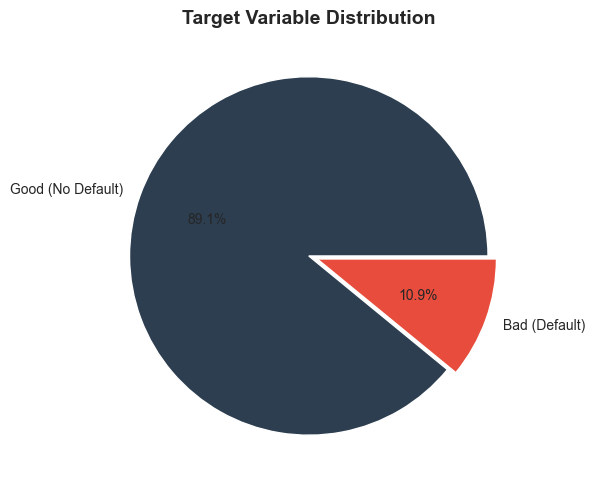

In [345]:
fig, ax = plt.subplots(figsize=(6, 6))
df_loans['target_bad'].value_counts().plot.pie(
    autopct='%1.1f%%',
    explode=[0, 0.05],
    labels=['Good (No Default)', 'Bad (Default)'],
    colors=['#2c3e50', '#e74c3c'],
    ax=ax
)
ax.set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [346]:
drop_cols = [
    # Identifiers (no predictive power)
    'Unnamed: 0', 'id', 'member_id', 'url', 'desc', 'title', 'zip_code', 'emp_title',
    
    # Constants / Internal flags (no variation)
    'policy_code', 'pymnt_plan',
    
    # Redundant (duplicate other columns)
    'sub_grade', 'funded_amnt_inv',
    
    # 100% Missing
    'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m',
    'mths_since_rcnt_il', 'total_bal_il', 'il_util',
    'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
    'inq_fi', 'total_cu_tl', 'inq_last_12m',
    
    # Look-Ahead / Post-Performance (occur AFTER loan is funded)
    'issue_d', 'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d',
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'last_pymnt_amnt'
]

df_loans.drop(columns=drop_cols, inplace=True, errors='ignore')

print(f"Columns dropped: {len(drop_cols)}")
print(f"Columns remaining: {df_loans.shape[1]}")

print(df_loans.columns.tolist())

Columns dropped: 38
Columns remaining: 38
['loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment', 'grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'loan_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'target_bad']


In [347]:
df_loans['term_int'] = df_loans['term'].str.replace(' months', '').astype(int)
print(f"'term' parsed to integer: {df_loans['term_int'].unique()}")

emp_map = {
    '10+ years': 10, '9 years': 9, '8 years': 8, '7 years': 7,
    '6 years': 6, '5 years': 5, '4 years': 4, '3 years': 3,
    '2 years': 2, '1 year': 1, '< 1 year': 0, 'n/a': 0
}
df_loans['emp_length_int'] = df_loans['emp_length'].map(emp_map).fillna(0).astype(int)
print(f"'emp_length' parsed to integer: {df_loans['emp_length_int'].unique()}")

'term' parsed to integer: [36 60]
'emp_length' parsed to integer: [10  0  1  3  8  9  4  5  6  2  7]


In [348]:
print(df_loans[['earliest_cr_line']].head(10))

df_loans['earliest_cr_line_date'] = pd.to_datetime(df_loans['earliest_cr_line'], format='%b-%y', errors='coerce')

ref_date = pd.to_datetime('2017-12-01')
df_loans['mths_since_earliest'] = ((ref_date - df_loans['earliest_cr_line_date']).dt.days / 30.44).round(0).fillna(0).astype(int)

negative_count = (df_loans['mths_since_earliest'] < 0).sum()
print(f"Rows with negative months (1969 bug): {negative_count}")

if negative_count > 0:
    max_val = df_loans['mths_since_earliest'].max()
    df_loans['mths_since_earliest'] = df_loans['mths_since_earliest'].clip(lower=0)
    print(f"Fixed by setting negative values to 0 (max value: {max_val})")

print(f"  Credit age range: {df_loans['mths_since_earliest'].min()} to {df_loans['mths_since_earliest'].max()} months")

df_loans.drop(columns=['term', 'emp_length', 'earliest_cr_line', 'earliest_cr_line_date'], inplace=True, errors='ignore')

  earliest_cr_line
0           Jan-85
1           Apr-99
2           Nov-01
3           Feb-96
4           Jan-96
5           Nov-04
6           Jul-05
7           Jan-07
8           Apr-04
9           Sep-04
Rows with negative months (1969 bug): 1169
Fixed by setting negative values to 0 (max value: 587)
  Credit age range: 0 to 587 months


In [349]:
print(f"Columns remaining: {df_loans.shape[1]}")
print(f"New columns added: 'term_int', 'emp_length_int', 'mths_since_earliest'")
print(f"Raw columns dropped: 'term', 'emp_length', 'earliest_cr_line', 'earliest_cr_line_date'")

Columns remaining: 38
New columns added: 'term_int', 'emp_length_int', 'mths_since_earliest'
Raw columns dropped: 'term', 'emp_length', 'earliest_cr_line', 'earliest_cr_line_date'


In [350]:
missing_fill_zero = [
    'mths_since_last_delinq',
    'mths_since_last_record',
    'mths_since_last_major_derog',
    'collections_12_mths_ex_med'
]

In [351]:
for col in missing_fill_zero:
    missing_count = df_loans[col].isnull().sum()
    if missing_count > 0:
        df_loans[col] = df_loans[col].fillna(0)
        print(f"{col}: {missing_count:,} missing values → set to 0")

mths_since_last_delinq: 250,351 missing values → set to 0
mths_since_last_record: 403,647 missing values → set to 0
mths_since_last_major_derog: 367,311 missing values → set to 0
collections_12_mths_ex_med: 145 missing values → set to 0


In [352]:
bureau_cols = [
    'delinq_2yrs', 'inq_last_6mths', 'open_acc',
    'pub_rec', 'total_acc', 'acc_now_delinq'
]

In [353]:
for col in bureau_cols:
    missing_count = df_loans[col].isnull().sum()
    if missing_count > 0:
        df_loans[col] = df_loans[col].fillna(0)
        print(f"{col}: {missing_count:,} missing values → set to 0")

delinq_2yrs: 29 missing values → set to 0
inq_last_6mths: 29 missing values → set to 0
open_acc: 29 missing values → set to 0
pub_rec: 29 missing values → set to 0
total_acc: 29 missing values → set to 0
acc_now_delinq: 29 missing values → set to 0


In [354]:
missing_count = df_loans['annual_inc'].isnull().sum()
if missing_count > 0:
    median_income = df_loans['annual_inc'].median()
    df_loans['annual_inc'] = df_loans['annual_inc'].fillna(median_income)
    print(f"annual_inc: {missing_count:,} missing values → set to median ({median_income:,.0f})")

annual_inc: 4 missing values → set to median (63,000)


In [355]:
missing_count = df_loans['revol_util'].isnull().sum()
if missing_count > 0:
    median_util = df_loans['revol_util'].median()
    df_loans['revol_util'] = df_loans['revol_util'].fillna(median_util)
    print(f"revol_util: {missing_count:,} missing values → set to median ({median_util:.1f}%)")

revol_util: 340 missing values → set to median (57.6%)


In [356]:
missing_count = df_loans['total_rev_hi_lim'].isnull().sum()
if missing_count > 0:
    df_loans['total_rev_hi_lim'] = df_loans['total_rev_hi_lim'].fillna(df_loans['funded_amnt'])
    print(f"total_rev_hi_lim: {missing_count:,} missing values → set to funded_amnt")

total_rev_hi_lim: 70,276 missing values → set to funded_amnt


In [357]:
for col in ['tot_coll_amt', 'tot_cur_bal']:
    missing_count = df_loans[col].isnull().sum()
    if missing_count > 0:
        df_loans[col] = df_loans[col].fillna(0)
        print(f"{col}: {missing_count:,} missing values → set to 0")

tot_coll_amt: 70,276 missing values → set to 0
tot_cur_bal: 70,276 missing values → set to 0


In [358]:
remaining_missing = df_loans.isnull().sum().sum()
print(f"Total missing values remaining: {remaining_missing}")

Total missing values remaining: 0


In [359]:
print(f"\nFinal shape: {df_loans.shape}")


Final shape: (466285, 38)


In [360]:
df_loans.drop(columns=['loan_status', 'application_type'], inplace=True, errors='ignore')

print(f"Shape after dropping useless columns: {df_loans.shape}")
print(f"Columns remaining: {df_loans.shape[1]}")

Shape after dropping useless columns: (466285, 36)
Columns remaining: 36


In [361]:
categorical_cols = ['grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status']
continuous_cols = ['loan_amnt', 'funded_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'revol_bal', 'revol_util', 'total_rev_hi_lim', 'tot_coll_amt', 'tot_cur_bal', 'mths_since_earliest', 'mths_since_last_delinq', 'mths_since_last_record', 'mths_since_last_major_derog']
discrete_cols = ['term_int', 'emp_length_int', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'total_acc', 'acc_now_delinq', 'collections_12_mths_ex_med']
lgd_cols = ['total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee']

print(f"\nCategorical: {len(categorical_cols)}")
print(f"Continuous: {len(continuous_cols)}")
print(f"Discrete: {len(discrete_cols)}")
print(f"LGD (later): {len(lgd_cols)}")
print(f"Target: 1 (target_bad)")
print(f"Total: {len(categorical_cols) + len(continuous_cols) + len(discrete_cols) + len(lgd_cols) + 1}")


Categorical: 6
Continuous: 15
Discrete: 9
LGD (later): 5
Target: 1 (target_bad)
Total: 36


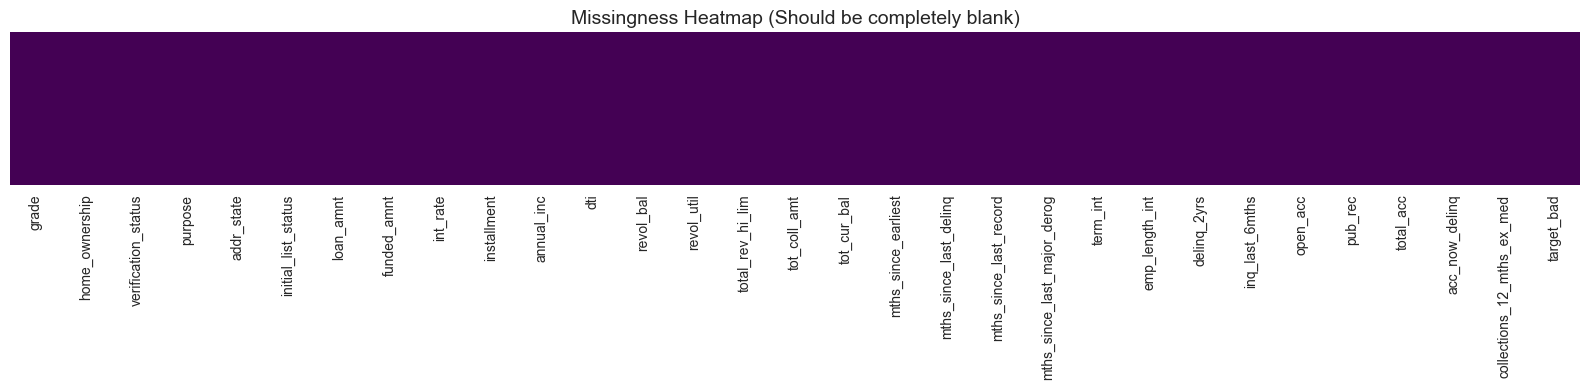

In [362]:
plt.figure(figsize=(16, 4))
sns.heatmap(df_loans[categorical_cols + continuous_cols + discrete_cols + ['target_bad']].isnull(),
            cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missingness Heatmap (Should be completely blank)', fontsize=14)
plt.tight_layout()
plt.show()

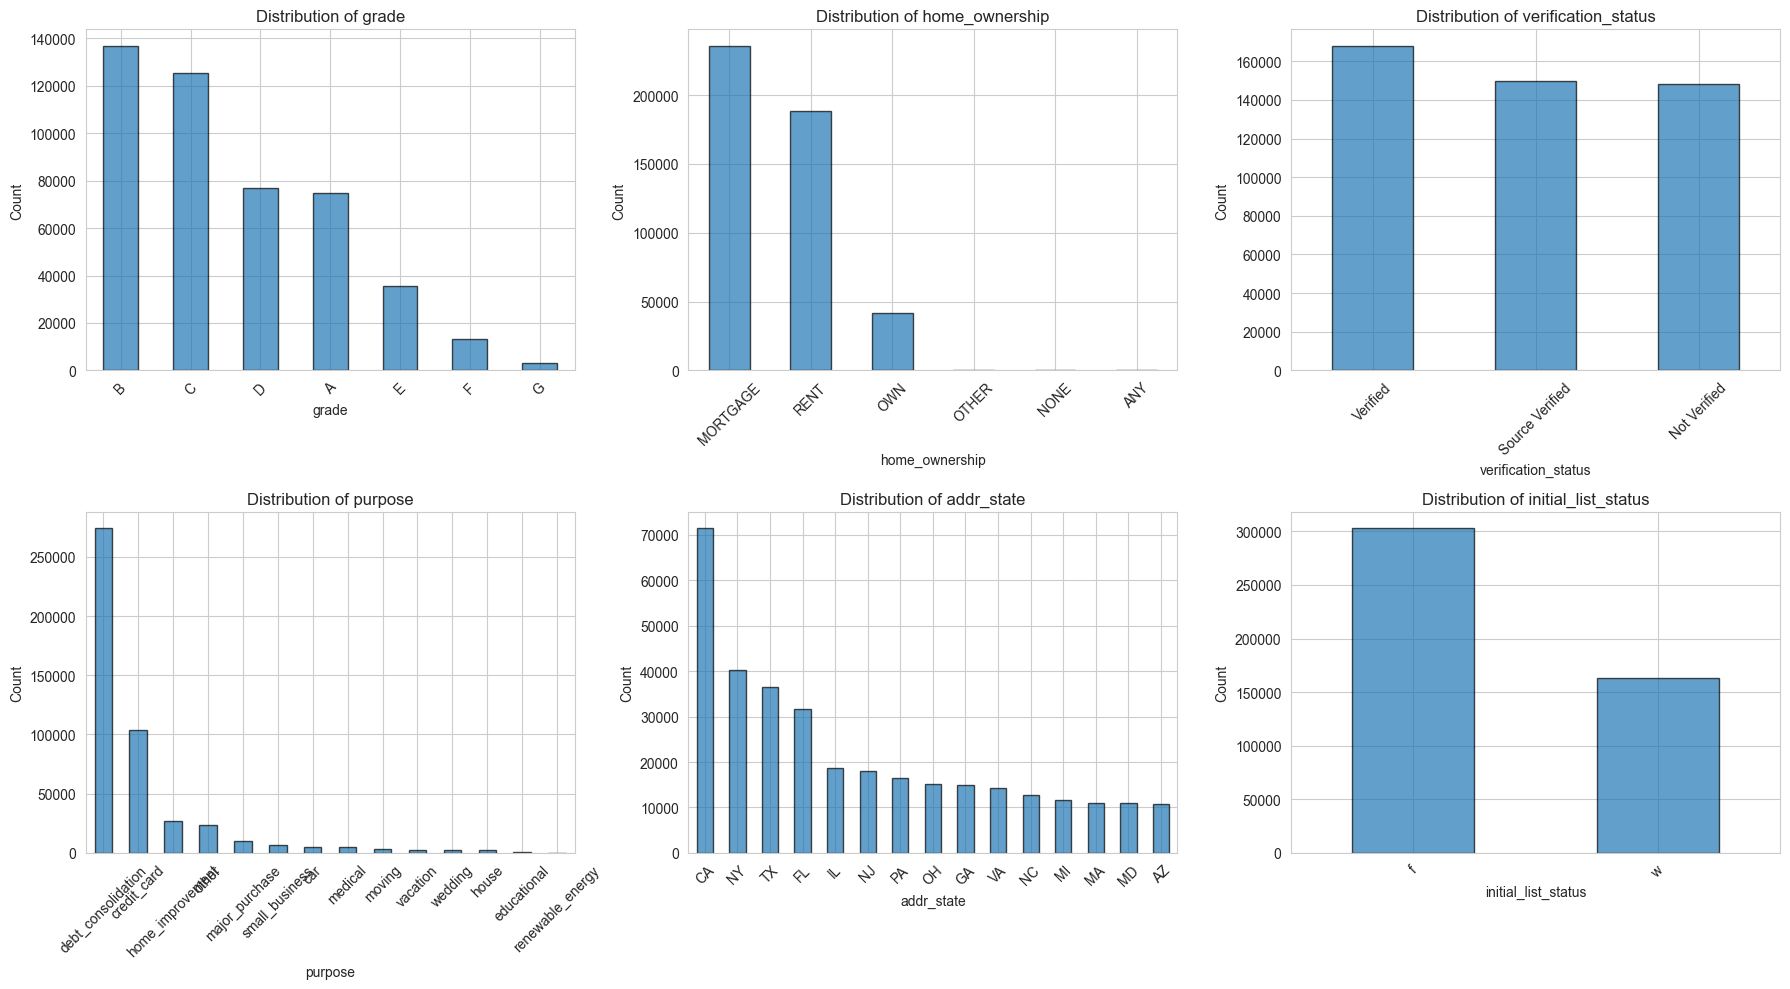

In [363]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    df_loans[col].value_counts().head(15).plot(kind='bar', ax=axes[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [364]:
for col in categorical_cols:
    print(f"\n{col.upper()}:")
    print(df_loans[col].value_counts().round(2))


GRADE:
grade
B    136929
C    125293
D     76888
A     74867
E     35757
F     13229
G      3322
Name: count, dtype: int64

HOME_OWNERSHIP:
home_ownership
MORTGAGE    235875
RENT        188473
OWN          41704
OTHER          182
NONE            50
ANY              1
Name: count, dtype: int64

VERIFICATION_STATUS:
verification_status
Verified           168055
Source Verified    149993
Not Verified       148237
Name: count, dtype: int64

PURPOSE:
purpose
debt_consolidation    274195
credit_card           104157
home_improvement       26537
other                  23690
major_purchase          9828
small_business          7013
car                     5397
medical                 4602
moving                  2994
vacation                2487
wedding                 2343
house                   2269
educational              422
renewable_energy         351
Name: count, dtype: int64

ADDR_STATE:
addr_state
CA    71450
NY    40242
TX    36439
FL    31637
IL    18612
NJ    18061
PA    16424


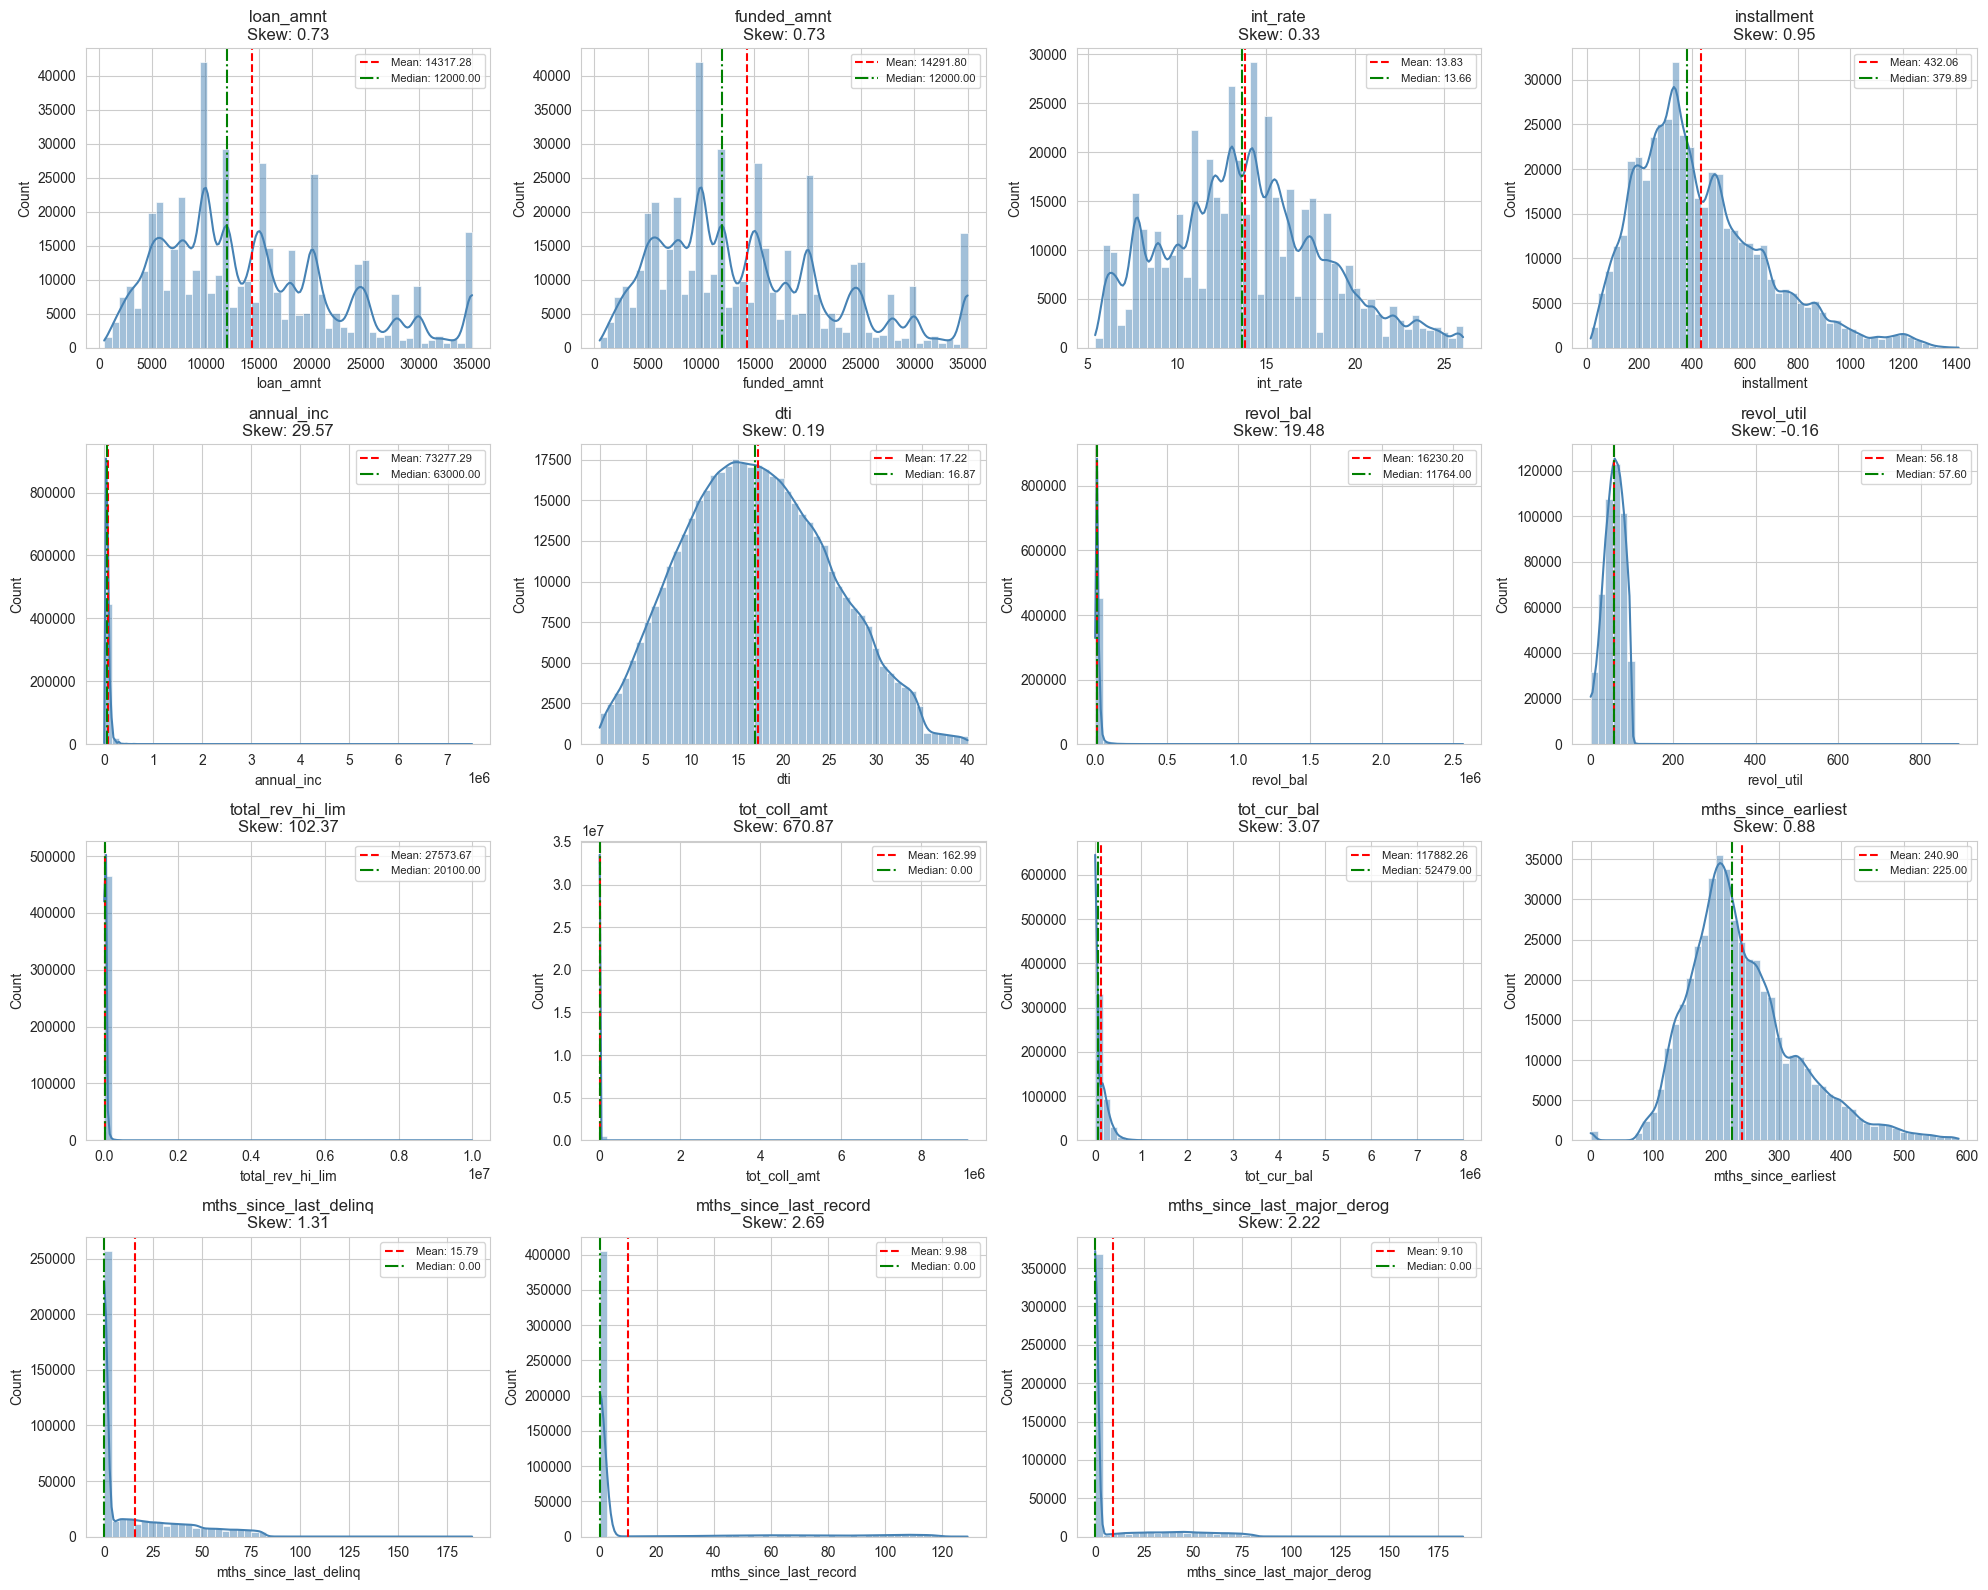

In [365]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
for i, col in enumerate(continuous_cols):
    sns.histplot(df_loans[col], kde=True, bins=50, color='steelblue', ax=axes[i])
    axes[i].axvline(df_loans[col].mean(), color='red', linestyle='--', label=f'Mean: {df_loans[col].mean():.2f}')
    axes[i].axvline(df_loans[col].median(), color='green', linestyle='-.', label=f'Median: {df_loans[col].median():.2f}')
    axes[i].set_title(f'{col}\nSkew: {df_loans[col].skew():.2f}')
    axes[i].legend(fontsize=8)
for j in range(len(continuous_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [366]:
for col in continuous_cols:
    print(f"\n{col.upper()}:")
    print(df_loans[col].describe().round(2))


LOAN_AMNT:
count    466285.00
mean      14317.28
std        8286.51
min         500.00
25%        8000.00
50%       12000.00
75%       20000.00
max       35000.00
Name: loan_amnt, dtype: float64

FUNDED_AMNT:
count    466285.00
mean      14291.80
std        8274.37
min         500.00
25%        8000.00
50%       12000.00
75%       20000.00
max       35000.00
Name: funded_amnt, dtype: float64

INT_RATE:
count    466285.00
mean         13.83
std           4.36
min           5.42
25%          10.99
50%          13.66
75%          16.49
max          26.06
Name: int_rate, dtype: float64

INSTALLMENT:
count    466285.00
mean        432.06
std         243.49
min          15.67
25%         256.69
50%         379.89
75%         566.58
max        1409.99
Name: installment, dtype: float64

ANNUAL_INC:
count     466285.00
mean       73277.29
std        54963.34
min         1896.00
25%        45000.00
50%        63000.00
75%        88953.00
max      7500000.00
Name: annual_inc, dtype: float64

DTI

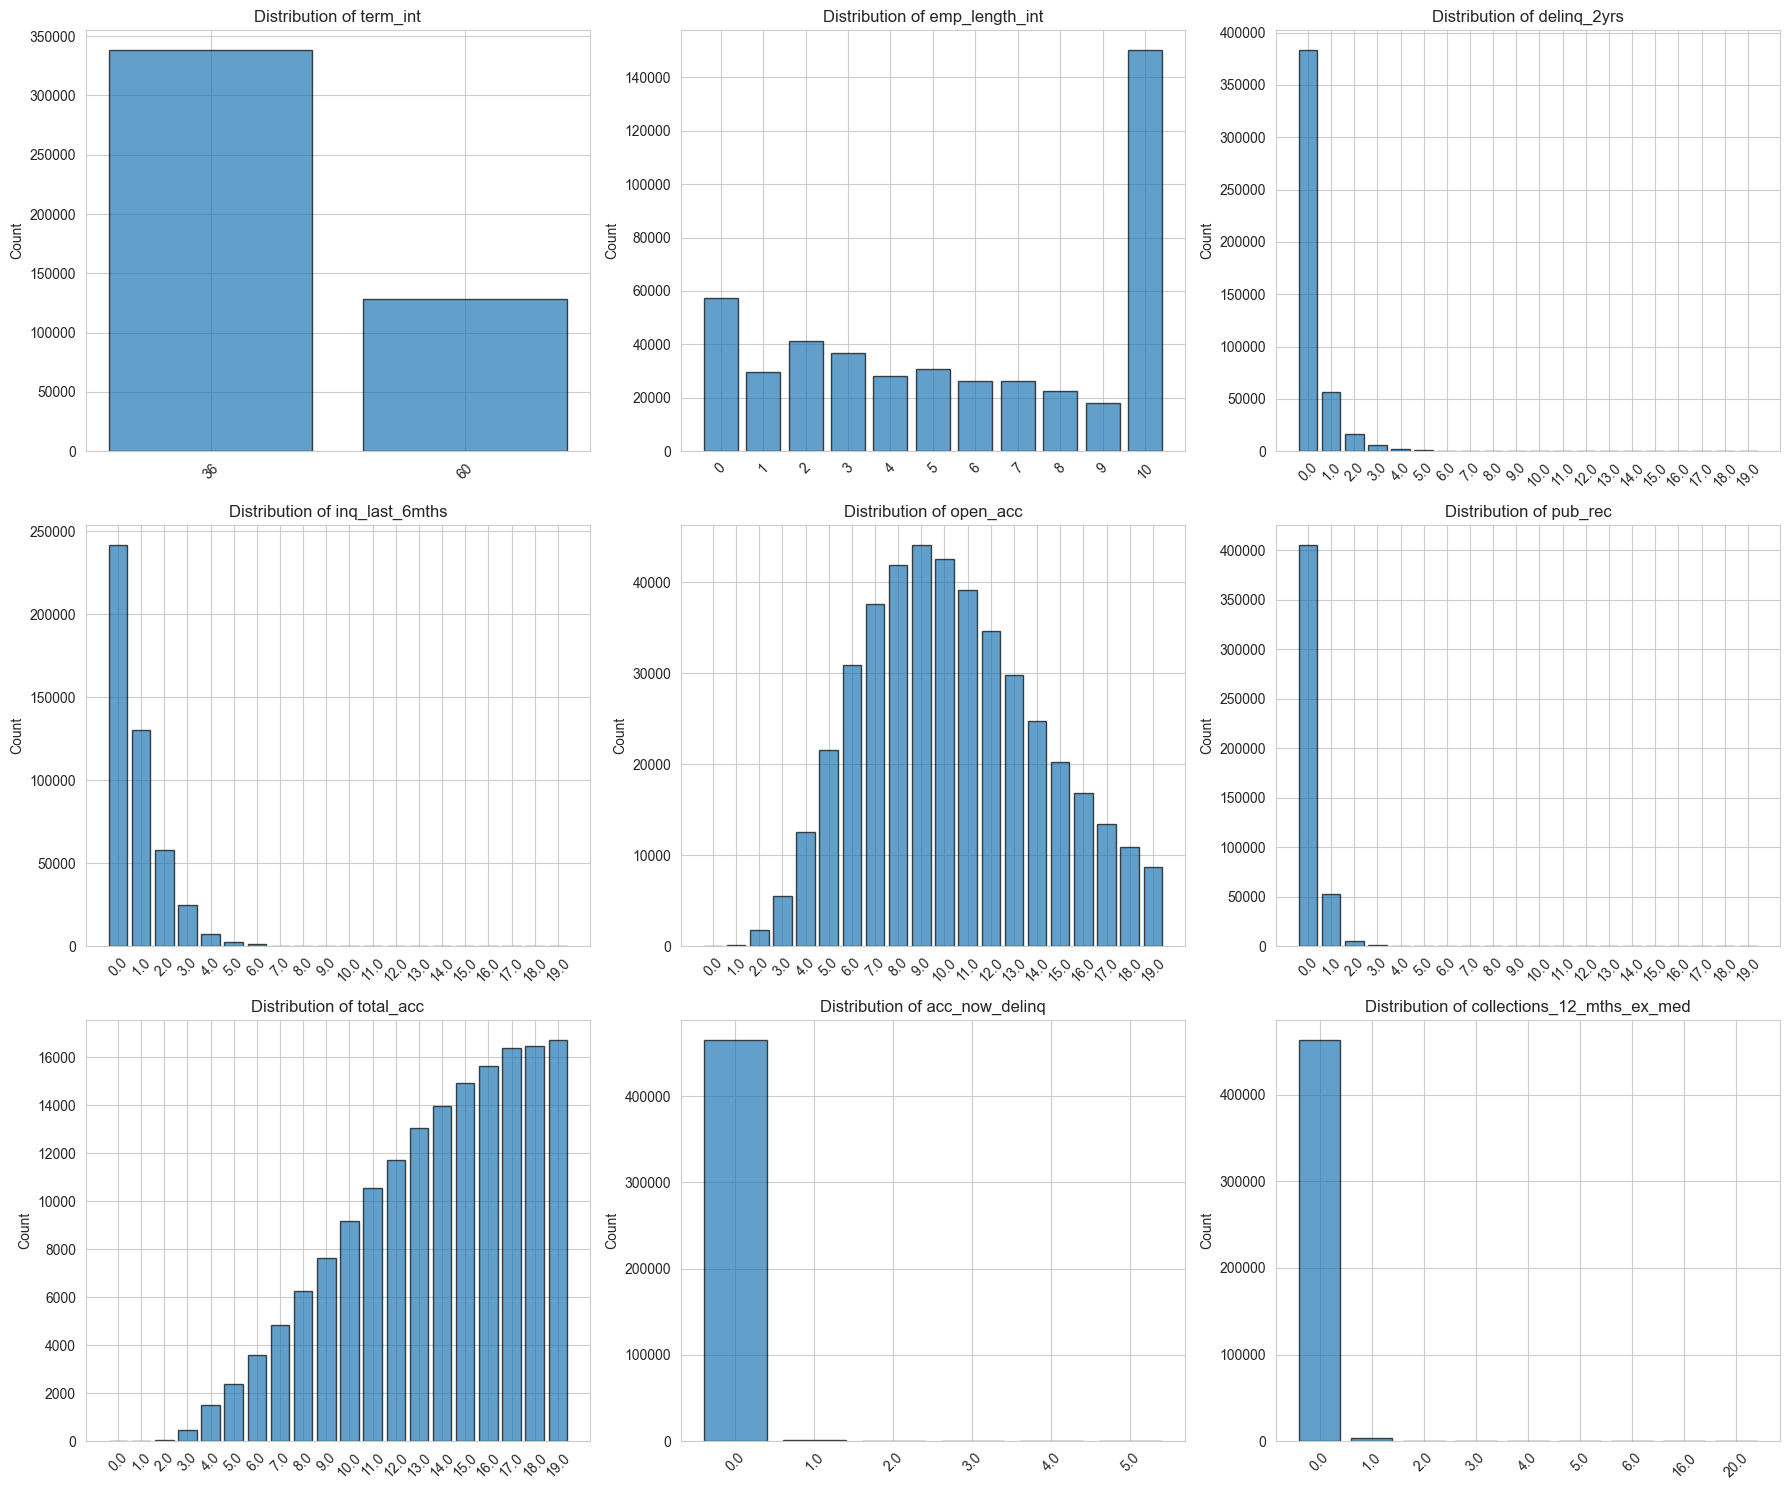

In [367]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()
for i, col in enumerate(discrete_cols):
    value_counts = df_loans[col].value_counts().sort_index().head(20)
    axes[i].bar(value_counts.index.astype(str), value_counts.values, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
for j in range(len(discrete_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [368]:
for col in discrete_cols:
    print(f"\n{col.upper()}:")
    print(df_loans[col].value_counts().round(2))


TERM_INT:
term_int
36    337953
60    128332
Name: count, dtype: int64

EMP_LENGTH_INT:
emp_length_int
10    150049
0      57273
2      41373
3      36596
5      30774
1      29622
4      28023
7      26180
6      26112
8      22395
9      17888
Name: count, dtype: int64

DELINQ_2YRS:
delinq_2yrs
0.0     382983
1.0      56224
2.0      16310
3.0       5684
4.0       2378
5.0       1236
6.0        629
7.0        346
8.0        177
9.0        111
10.0        65
11.0        41
12.0        38
13.0        25
14.0         8
15.0         7
18.0         6
16.0         5
17.0         3
19.0         3
21.0         2
22.0         2
29.0         1
24.0         1
Name: count, dtype: int64

INQ_LAST_6MTHS:
inq_last_6mths
0.0     241527
1.0     130148
2.0      57825
3.0      25126
4.0       7241
5.0       2768
6.0       1188
7.0        195
8.0        122
9.0         50
10.0        24
11.0        15
12.0        15
15.0         9
14.0         6
13.0         6
18.0         4
16.0         3
17.0         

In [369]:
overall_default = df_loans['target_bad'].mean()
print(f"Overall Default Rate: {overall_default:.2%}")

Overall Default Rate: 10.93%


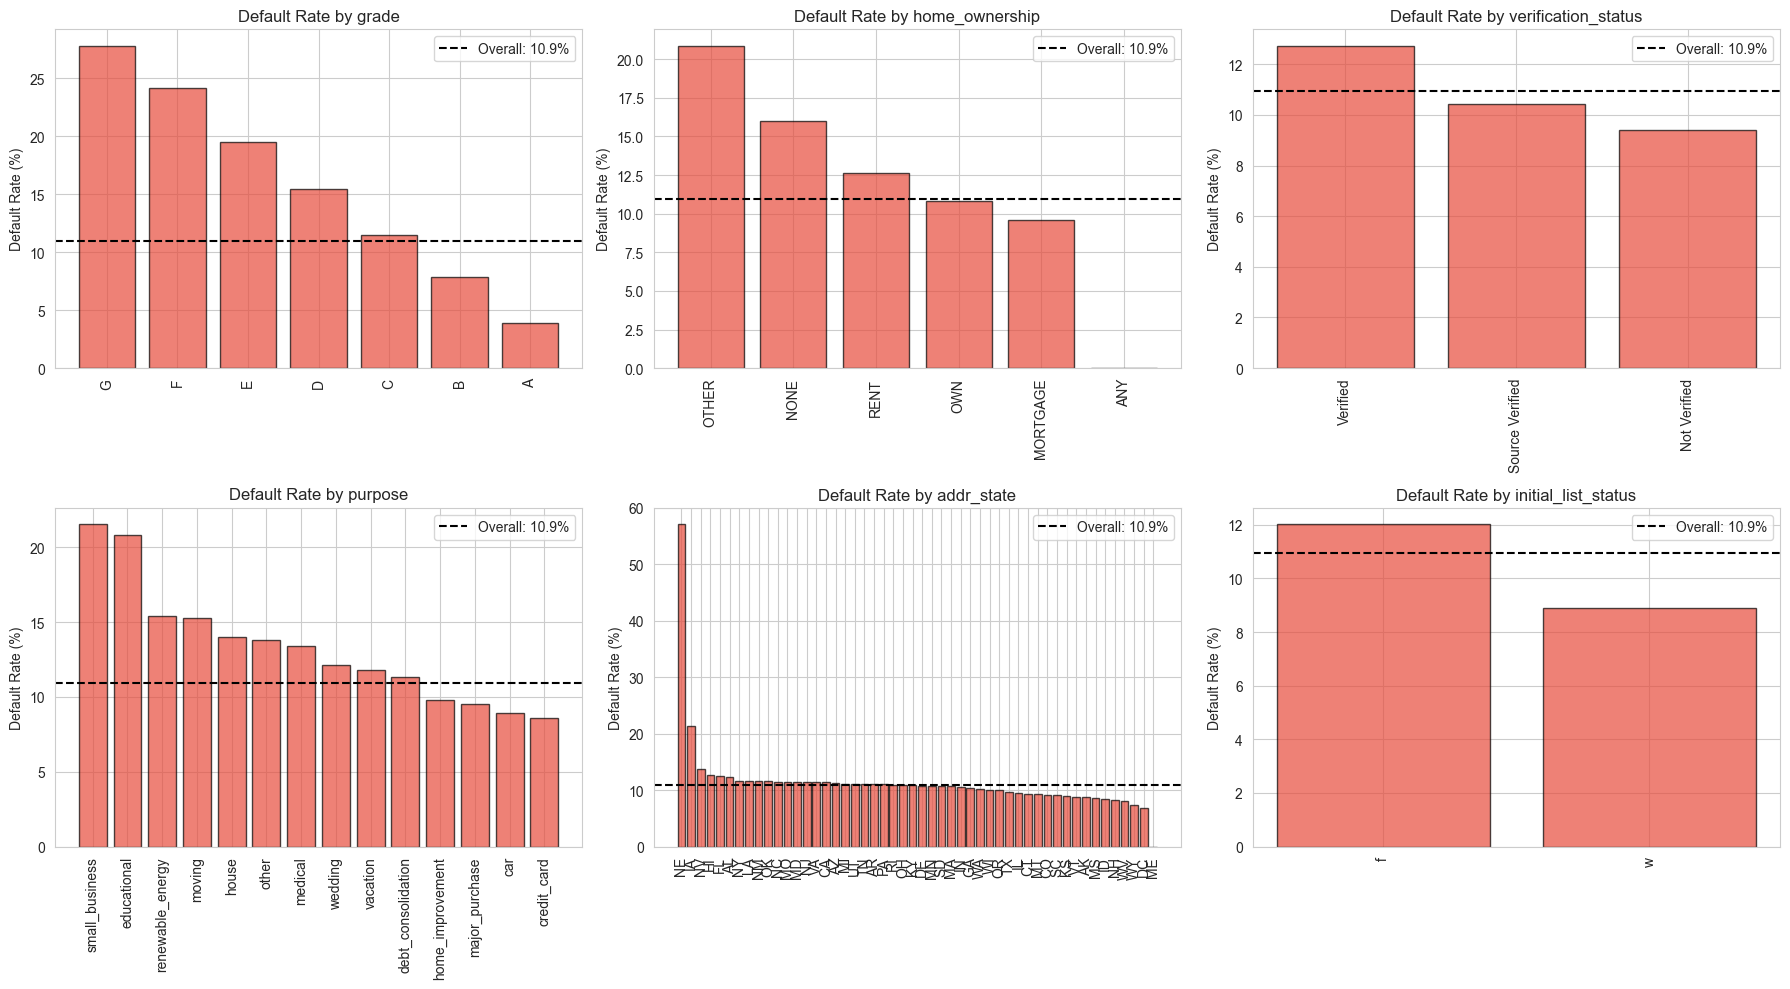

In [370]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    default_rate = df_loans.groupby(col)['target_bad'].mean().sort_values(ascending=False)
    axes[i].bar(default_rate.index.astype(str), default_rate.values * 100, edgecolor='black', alpha=0.7, color='#e74c3c')
    axes[i].axhline(y=overall_default * 100, color='black', linestyle='--', label=f'Overall: {overall_default:.1%}')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].legend()
for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [371]:
for col in categorical_cols:
    print(f"\n{col.upper()}:")
    default_rate = df_loans.groupby(col)['target_bad'].mean().sort_values(ascending=False)
    counts = df_loans.groupby(col)['target_bad'].count()
    table = pd.DataFrame({
        'Count': counts,
        'Default_Rate': (default_rate * 100).round(2)
    })
    print(table.to_string())


GRADE:
        Count  Default_Rate
grade                      
A       74867          3.87
B      136929          7.86
C      125293         11.48
D       76888         15.41
E       35757         19.48
F       13229         24.13
G        3322         27.81

HOME_OWNERSHIP:
                 Count  Default_Rate
home_ownership                      
ANY                  1          0.00
MORTGAGE        235875          9.60
NONE                50         16.00
OTHER              182         20.88
OWN              41704         10.83
RENT            188473         12.61

VERIFICATION_STATUS:
                      Count  Default_Rate
verification_status                      
Not Verified         148237          9.41
Source Verified      149993         10.41
Verified             168055         12.74

PURPOSE:
                     Count  Default_Rate
purpose                                 
car                   5397          8.91
credit_card         104157          8.62
debt_consolidation  2

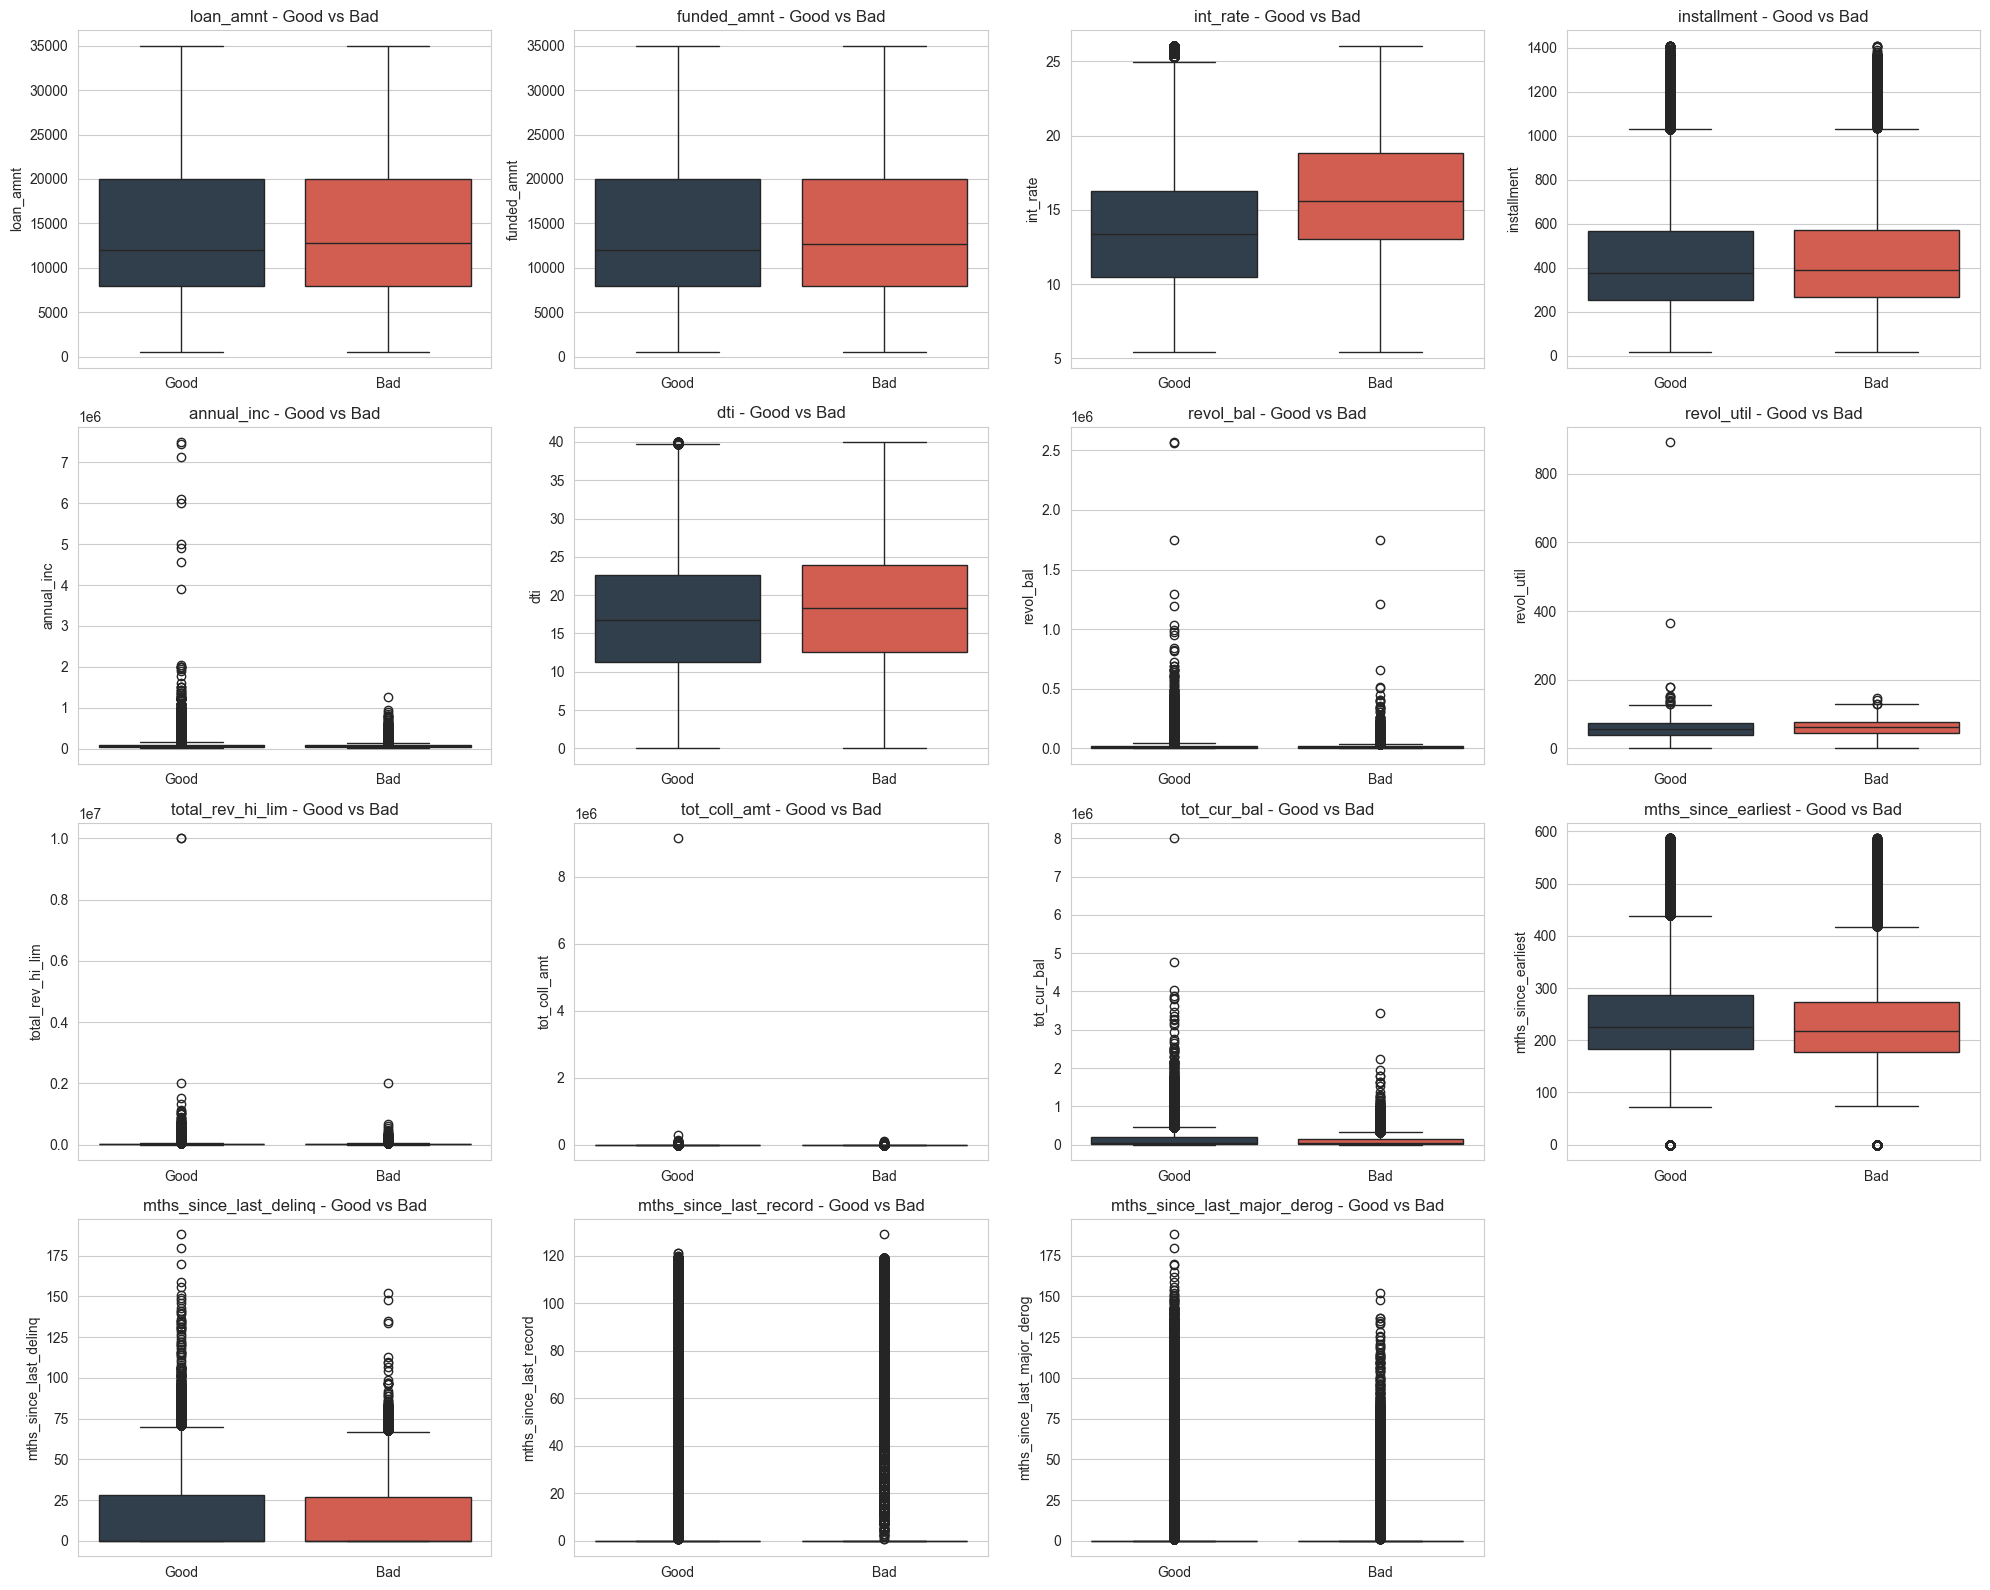

In [372]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
for i, col in enumerate(continuous_cols):
    plot_data = df_loans[['target_bad', col]].copy()
    plot_data['target_bad'] = plot_data['target_bad'].map({0: 'Good', 1: 'Bad'})
    sns.boxplot(x='target_bad', y=col, data=plot_data, ax=axes[i], palette=['#2c3e50', '#e74c3c'])
    axes[i].set_title(f'{col} - Good vs Bad')
    axes[i].set_xlabel('')
for j in range(len(continuous_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [373]:
for col in continuous_cols:
    print(f"\n{col.upper()}:")
    stats = df_loans.groupby('target_bad')[col].describe()
    # Rename index for clarity
    stats.index = ['Bad (1)', 'Good (0)']
    print(stats.round(2))


LOAN_AMNT:
             count      mean      std    min     25%      50%      75%  \
Bad (1)   415317.0  14282.97  8274.29  500.0  8000.0  12000.0  20000.0   
Good (0)   50968.0  14596.85  8380.23  500.0  8000.0  12800.0  20000.0   

              max  
Bad (1)   35000.0  
Good (0)  35000.0  

FUNDED_AMNT:
             count      mean      std    min     25%      50%      75%  \
Bad (1)   415317.0  14259.91  8263.64  500.0  8000.0  12000.0  20000.0   
Good (0)   50968.0  14551.70  8356.85  500.0  8000.0  12650.0  20000.0   

              max  
Bad (1)   35000.0  
Good (0)  35000.0  

INT_RATE:
             count   mean   std   min    25%    50%    75%    max
Bad (1)   415317.0  13.57  4.30  5.42  10.49  13.35  16.29  26.06
Good (0)   50968.0  15.97  4.26  5.42  13.05  15.61  18.85  26.06

INSTALLMENT:
             count    mean     std    min     25%     50%     75%      max
Bad (1)   415317.0  430.87  243.14  15.67  255.18  378.20  565.35  1409.99
Good (0)   50968.0  441.75  246.07 

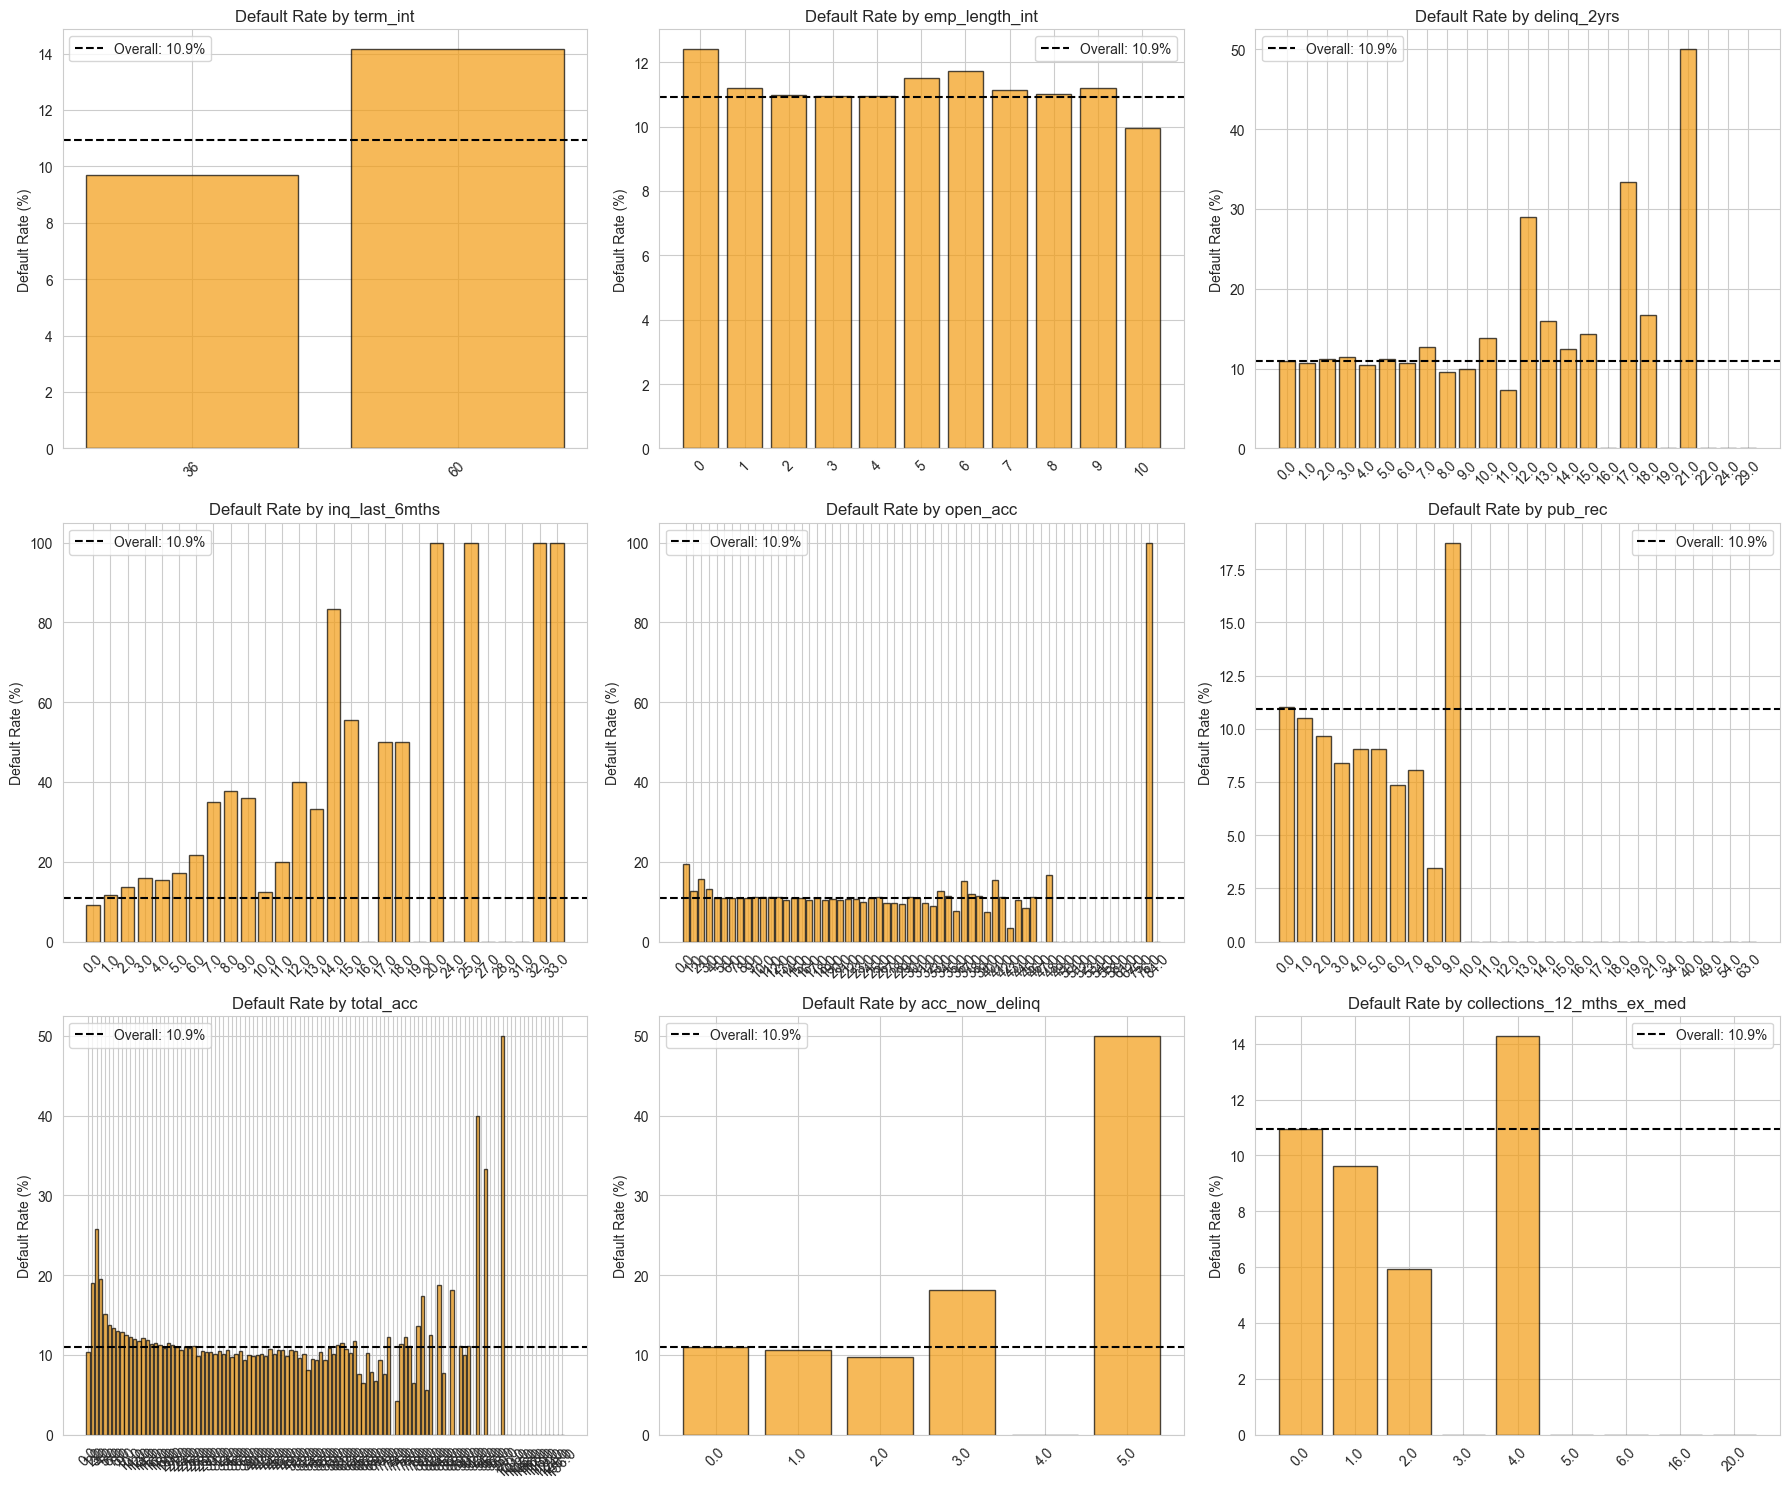

In [374]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(discrete_cols):
    # Calculate default rate per discrete value
    default_rate = df_loans.groupby(col)['target_bad'].mean().sort_index()
    
    # Plot as bar chart
    axes[i].bar(default_rate.index.astype(str), default_rate.values * 100, 
                edgecolor='black', alpha=0.7, color='#f39c12')
    axes[i].axhline(y=overall_default * 100, color='black', linestyle='--', 
                    label=f'Overall: {overall_default:.1%}')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend()

for j in range(len(discrete_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [375]:
for col in discrete_cols:
    default_rate = df_loans.groupby(col)['target_bad'].mean().sort_index()
    print(f"\n{col}:")
    print(default_rate.round(4) * 100)


term_int:
term_int
36     9.71
60    14.15
Name: target_bad, dtype: float64

emp_length_int:
emp_length_int
0     12.40
1     11.19
2     10.98
3     10.95
4     10.96
5     11.50
6     11.71
7     11.13
8     11.01
9     11.21
10     9.96
Name: target_bad, dtype: float64

delinq_2yrs:
delinq_2yrs
0.0     10.94
1.0     10.73
2.0     11.18
3.0     11.47
4.0     10.39
5.0     11.17
6.0     10.65
7.0     12.72
8.0      9.60
9.0      9.91
10.0    13.85
11.0     7.32
12.0    28.95
13.0    16.00
14.0    12.50
15.0    14.29
16.0     0.00
17.0    33.33
18.0    16.67
19.0     0.00
21.0    50.00
22.0     0.00
24.0     0.00
29.0     0.00
Name: target_bad, dtype: float64

inq_last_6mths:
inq_last_6mths
0.0       9.13
1.0      11.56
2.0      13.64
3.0      15.90
4.0      15.30
5.0      17.16
6.0      21.63
7.0      34.87
8.0      37.70
9.0      36.00
10.0     12.50
11.0     20.00
12.0     40.00
13.0     33.33
14.0     83.33
15.0     55.56
16.0      0.00
17.0     50.00
18.0     50.00
19.0      0.00

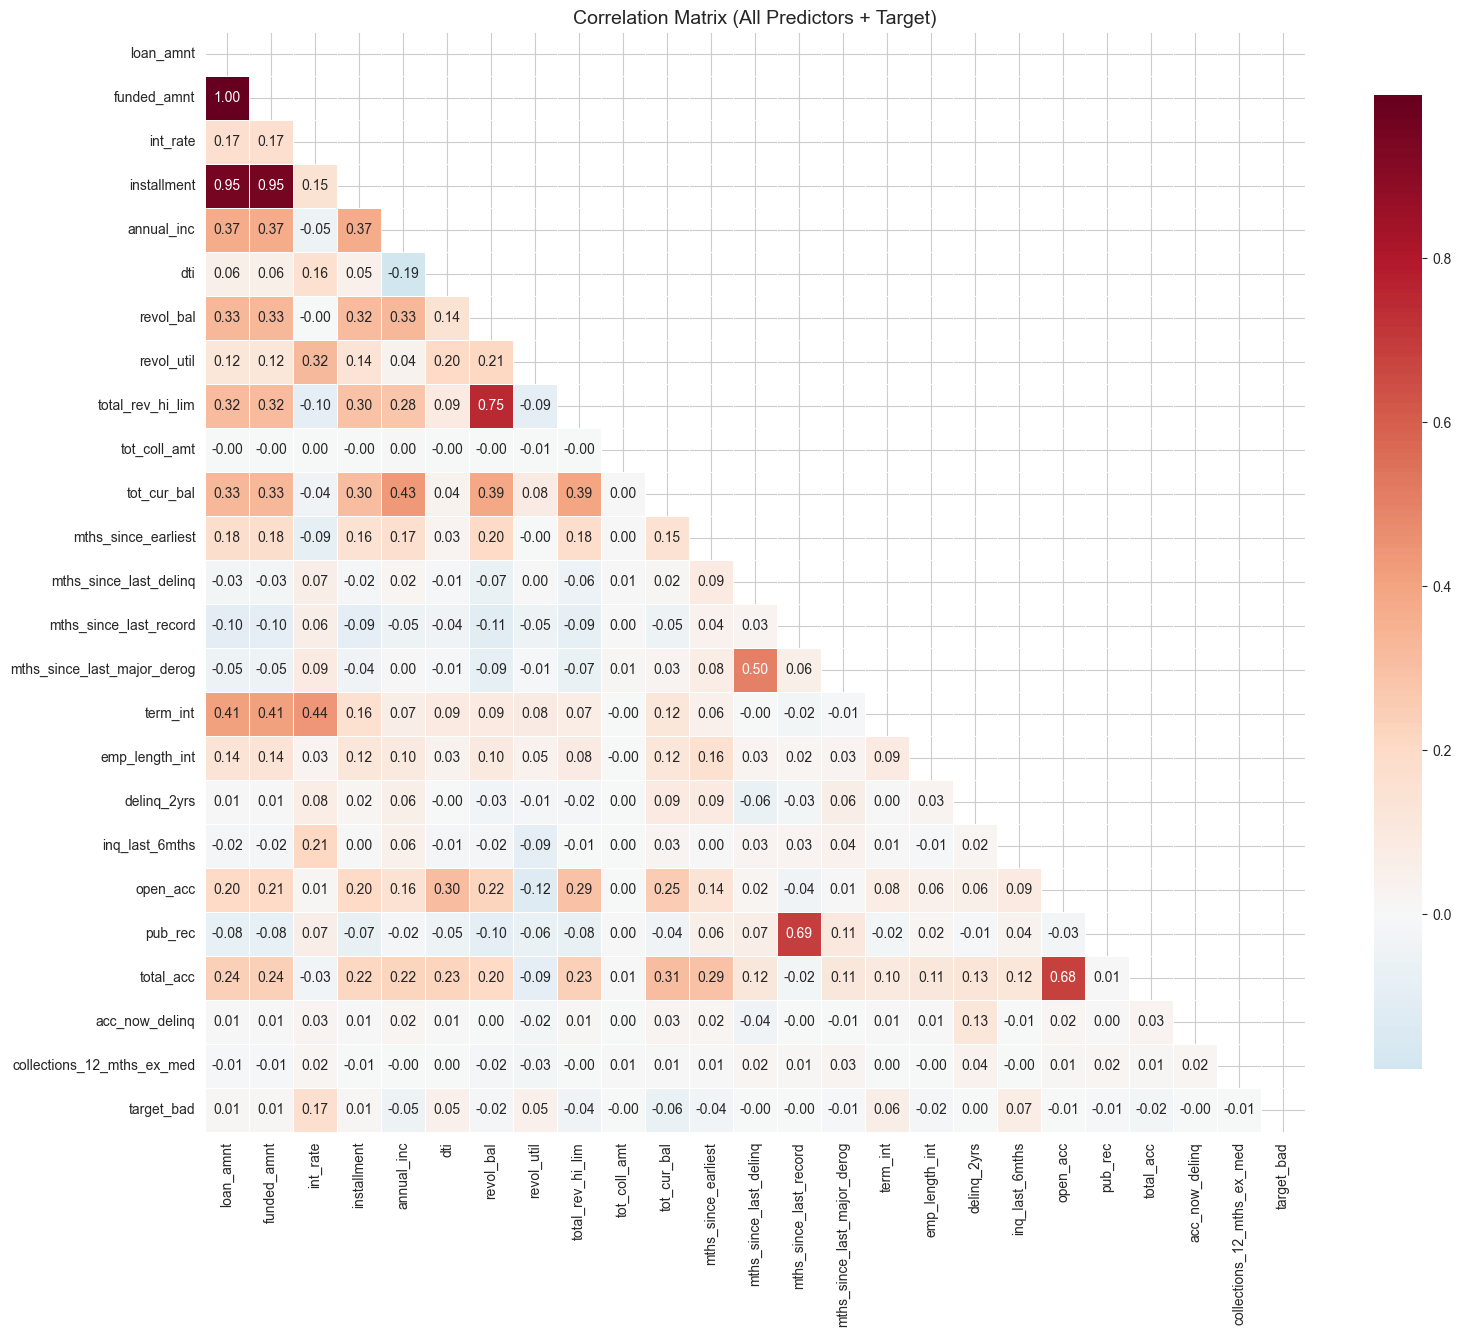

In [376]:
corr_cols = continuous_cols + discrete_cols + ['target_bad']
corr_matrix = df_loans[corr_cols].corr()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix (All Predictors + Target)', fontsize=14)
plt.tight_layout()
plt.show()

In [377]:
corr_target = corr_matrix['target_bad'].drop('target_bad').abs().sort_values(ascending=False)
print(corr_target.round(3))

int_rate                       0.172
inq_last_6mths                 0.073
tot_cur_bal                    0.064
term_int                       0.064
revol_util                     0.050
annual_inc                     0.050
dti                            0.048
total_rev_hi_lim               0.042
mths_since_earliest            0.035
total_acc                      0.023
emp_length_int                 0.021
revol_bal                      0.018
installment                    0.014
loan_amnt                      0.012
mths_since_last_major_derog    0.011
funded_amnt                    0.011
pub_rec                        0.009
open_acc                       0.006
collections_12_mths_ex_med     0.005
mths_since_last_delinq         0.005
tot_coll_amt                   0.001
delinq_2yrs                    0.001
mths_since_last_record         0.000
acc_now_delinq                 0.000
Name: target_bad, dtype: float64


In [378]:
def calc_woe(df, feature, target='target_bad'):
    """
    Calculate Weight of Evidence and Information Value.
    APPLIES 0.5 SMOOTHING to avoid division by zero.
    
    Parameters:
    - df: DataFrame
    - feature: column name (str)
    - target: target column name (default: 'target_bad')
    
    Returns:
    - woe_df: DataFrame with WoE and IV contribution per category
    - total_iv: Total Information Value for the variable
    """
    # Cross-tabulation
    crosstab = pd.crosstab(df[feature], df[target])
    
    # Ensure both classes exist
    if 0 not in crosstab.columns:
        crosstab[0] = 0
    if 1 not in crosstab.columns:
        crosstab[1] = 0
    
    crosstab['Good'] = crosstab[0]
    crosstab['Bad'] = crosstab[1]
    
    total_good = crosstab['Good'].sum()
    total_bad = crosstab['Bad'].sum()
    
    # Raw percentages
    crosstab['Good%'] = (crosstab['Good'] / total_good * 100).round(2)
    crosstab['Bad%'] = (crosstab['Bad'] / total_bad * 100).round(2)
    
    # SMOOTHING: Add 0.5 to numerator and 1 to denominator
    crosstab['Good%_adj'] = ((crosstab['Good'] + 0.5) / (total_good + 1) * 100).round(4)
    crosstab['Bad%_adj'] = ((crosstab['Bad'] + 0.5) / (total_bad + 1) * 100).round(4)
    
    # WoE = ln(Good%_adj / Bad%_adj)
    crosstab['WoE'] = np.log(crosstab['Good%_adj'] / crosstab['Bad%_adj']).round(4)
    
    # IV Contribution = (Good% - Bad%) * WoE / 100
    crosstab['IV_contrib'] = ((crosstab['Good%'] - crosstab['Bad%']) / 100) * crosstab['WoE']
    
    # Total IV
    total_iv = crosstab['IV_contrib'].sum().round(6)
    
    # Return clean DataFrame
    result = crosstab.reset_index()[[feature, 'Good', 'Bad', 'Good%', 'Bad%', 'WoE', 'IV_contrib']]
    result = result.sort_values('WoE', ascending=True).reset_index(drop=True)
    
    return result, total_iv

In [379]:
continuous_to_bin = [
    'loan_amnt', 'funded_amnt', 'int_rate', 'installment', 
    'annual_inc', 'dti', 'revol_bal', 'revol_util', 
    'total_rev_hi_lim', 'tot_coll_amt', 'tot_cur_bal', 
    'mths_since_earliest', 'mths_since_last_delinq', 
    'mths_since_last_record', 'mths_since_last_major_derog'
]

for col in continuous_to_bin:
    df_loans[f'{col}_bin'] = pd.qcut(df_loans[col], q=50, duplicates='drop')

In [380]:
discrete_to_bin = [
    'term_int', 'emp_length_int', 'delinq_2yrs', 'inq_last_6mths',
    'open_acc', 'pub_rec', 'total_acc', 'acc_now_delinq', 
    'collections_12_mths_ex_med'
]

for col in discrete_to_bin:
    df_loans[f'{col}_cat'] = df_loans[col].astype(str)

In [381]:
iv_results = []

categorical_to_use = ['grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status']

print("\nCategorical variables:")
for col in categorical_to_use:
    _, iv = calc_woe(df_loans, col, target='target_bad')
    iv_results.append({'Variable': col, 'IV': iv, 'Type': 'Categorical'})
    print(f"{col}: IV = {iv:.4f}")

print("\nContinuous variables (binned):")
for col in continuous_to_bin:
    bin_col = f'{col}_bin'
    if bin_col in df_loans.columns:
        _, iv = calc_woe(df_loans, bin_col, target='target_bad')
        iv_results.append({'Variable': col, 'IV': iv, 'Type': 'Continuous (Binned)'})
        print(f"{col}: IV = {iv:.4f}")

print("\nDiscrete variables (categorized):")
for col in discrete_to_bin:
    cat_col = f'{col}_cat'
    if cat_col in df_loans.columns:
        _, iv = calc_woe(df_loans, cat_col, target='target_bad')
        iv_results.append({'Variable': col, 'IV': iv, 'Type': 'Discrete'})
        print(f"{col}: IV = {iv:.4f}")


Categorical variables:
grade: IV = 0.2907
home_ownership: IV = 0.0217
verification_status: IV = 0.0208
purpose: IV = 0.0370
addr_state: IV = 0.0126
initial_list_status: IV = 0.0248

Continuous variables (binned):
loan_amnt: IV = 0.0142
funded_amnt: IV = 0.0142
int_rate: IV = 0.3608
installment: IV = 0.0124
annual_inc: IV = 0.0563
dti: IV = 0.0271
revol_bal: IV = 0.0076
revol_util: IV = 0.0288
total_rev_hi_lim: IV = 0.0458
tot_coll_amt: IV = 0.0024
tot_cur_bal: IV = 0.0637
mths_since_earliest: IV = 0.0168
mths_since_last_delinq: IV = 0.0012
mths_since_last_record: IV = 0.0057
mths_since_last_major_derog: IV = 0.0021

Discrete variables (categorized):
term_int: IV = 0.0389
emp_length_int: IV = 0.0066
delinq_2yrs: IV = 0.0003
inq_last_6mths: IV = 0.0518
open_acc: IV = 0.0023
pub_rec: IV = 0.0011
total_acc: IV = 0.0095
acc_now_delinq: IV = 0.0000
collections_12_mths_ex_med: IV = 0.0003


In [382]:
iv_summary = pd.DataFrame(iv_results).sort_values('IV', ascending=False)
print(iv_summary.round(4).to_string(index=False))

                   Variable     IV                Type
                   int_rate 0.3608 Continuous (Binned)
                      grade 0.2907         Categorical
                tot_cur_bal 0.0637 Continuous (Binned)
                 annual_inc 0.0563 Continuous (Binned)
             inq_last_6mths 0.0518            Discrete
           total_rev_hi_lim 0.0458 Continuous (Binned)
                   term_int 0.0389            Discrete
                    purpose 0.0370         Categorical
                 revol_util 0.0288 Continuous (Binned)
                        dti 0.0271 Continuous (Binned)
        initial_list_status 0.0248         Categorical
             home_ownership 0.0217         Categorical
        verification_status 0.0208         Categorical
        mths_since_earliest 0.0168 Continuous (Binned)
                funded_amnt 0.0142 Continuous (Binned)
                  loan_amnt 0.0142 Continuous (Binned)
                 addr_state 0.0126         Categorical
          

In [383]:
low_iv_vars = iv_summary[iv_summary['IV'] < 0.02]['Variable'].tolist()
print(f"Variables to drop (IV < 0.02): {len(low_iv_vars)}")
print(low_iv_vars)

Variables to drop (IV < 0.02): 17
['mths_since_earliest', 'funded_amnt', 'loan_amnt', 'addr_state', 'installment', 'total_acc', 'revol_bal', 'emp_length_int', 'mths_since_last_record', 'tot_coll_amt', 'open_acc', 'mths_since_last_major_derog', 'mths_since_last_delinq', 'pub_rec', 'delinq_2yrs', 'collections_12_mths_ex_med', 'acc_now_delinq']


In [384]:
drop_columns = []
for var in low_iv_vars:
    if var in df_loans.columns:
        drop_columns.append(var)
    if f'{var}_bin' in df_loans.columns:
        drop_columns.append(f'{var}_bin')
    if f'{var}_cat' in df_loans.columns:
        drop_columns.append(f'{var}_cat')

df_loans.drop(columns=drop_columns, inplace=True, errors='ignore')

print(f"Dropped {len(drop_columns)} columns")
print(f"Columns remaining: {df_loans.shape[1]}")

Dropped 33 columns
Columns remaining: 27


In [385]:
def plot_woe(df, feature, target='target_bad', figsize=(12, 6)):
    woe_df, iv = calc_woe(df, feature, target)
    woe_df = woe_df.sort_values('WoE')
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(woe_df[feature].astype(str), woe_df['WoE'], 
            marker='o', linestyle='-', linewidth=2, markersize=8, color='#2c3e50')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Weight of Evidence (WoE)', fontsize=12)
    ax.set_title(f'WoE by {feature} (IV: {iv:.4f})', fontsize=14)
    if len(woe_df) > 8:
        plt.xticks(rotation=45, ha='right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return woe_df, iv

IV: 0.3608
target_bad    int_rate_bin   Good   Bad  Good%  Bad%     WoE    IV_contrib
0            (22.4, 23.83]   6741  2179   1.62  4.28 -0.9686  2.576476e-02
1           (23.83, 26.06]   6932  2107   1.67  4.13 -0.9071  2.231466e-02
2             (21.0, 22.4]   7718  2153   1.86  4.22 -0.8213  1.938268e-02
3             (20.2, 21.0]   7240  1835   1.74  3.60 -0.7254  1.349244e-02
4           (17.57, 17.77]   4279  1061   1.03  2.08 -0.7037  7.388850e-03
5           (18.25, 18.75]   6403  1556   1.54  3.05 -0.6834  1.031934e-02
6           (18.75, 19.05]   6889  1569   1.66  3.08 -0.6186  8.784120e-03
7            (19.52, 20.2]   6787  1490   1.63  2.92 -0.5818  7.505220e-03
8            (15.61, 15.8]   4296   886   1.03  1.74 -0.5196  3.689160e-03
9           (19.05, 19.52]   7865  1566   1.89  3.07 -0.4841  5.712380e-03
10          (17.77, 18.25]   8415  1556   2.03  3.05 -0.4102  4.184040e-03
11           (17.1, 17.57]  13416  2436   3.23  4.78 -0.3919  6.074450e-03
12          (1

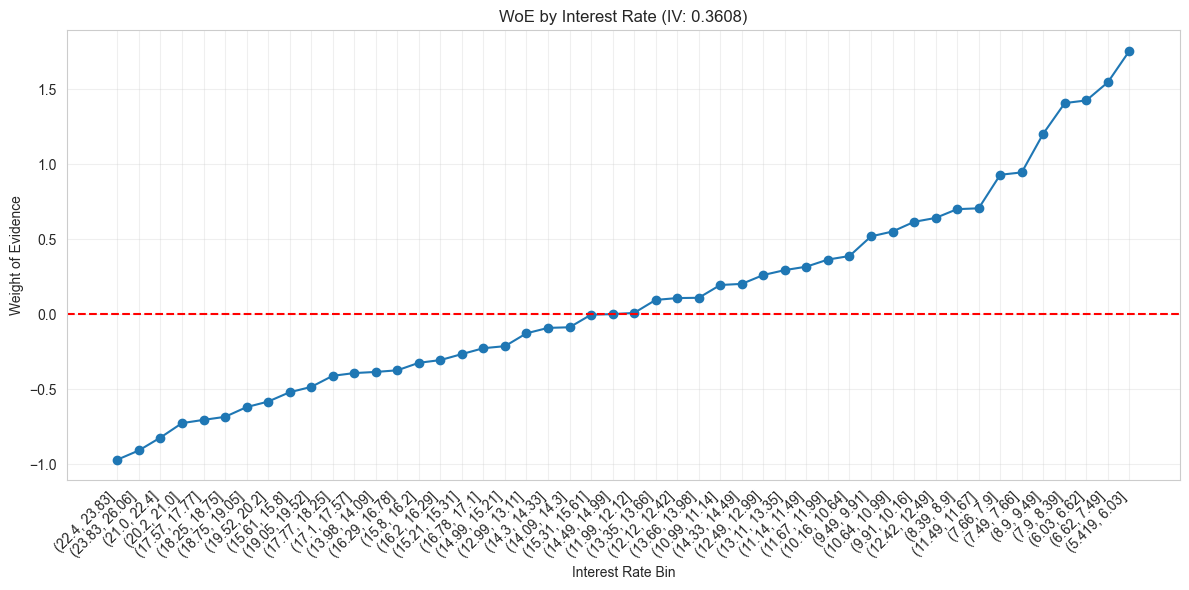

In [386]:
woe_int_rate, iv_int_rate = calc_woe(df_loans, 'int_rate_bin')
print(f"IV: {iv_int_rate:.4f}")
print(woe_int_rate)

plt.figure(figsize=(12, 6))
plt.plot(woe_int_rate['int_rate_bin'].astype(str), woe_int_rate['WoE'], marker='o', linestyle='-')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Interest Rate Bin')
plt.ylabel('Weight of Evidence')
plt.title(f'WoE by Interest Rate (IV: {iv_int_rate:.4f})')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

IV: 0.2907
target_bad grade    Good    Bad  Good%   Bad%     WoE  IV_contrib
0              G    2398    924   0.58   1.81 -1.1445    0.014077
1              F   10037   3192   2.42   6.26 -0.9523    0.036568
2              E   28793   6964   6.93  13.66 -0.6785    0.045663
3              D   65040  11848  15.66  23.25 -0.3950    0.029981
4              C  110909  14384  26.70  28.22 -0.0553    0.000841
5              B  126170  10759  30.38  21.11  0.3640    0.033743
6              A   71970   2897  17.33   5.68  1.1146    0.129851


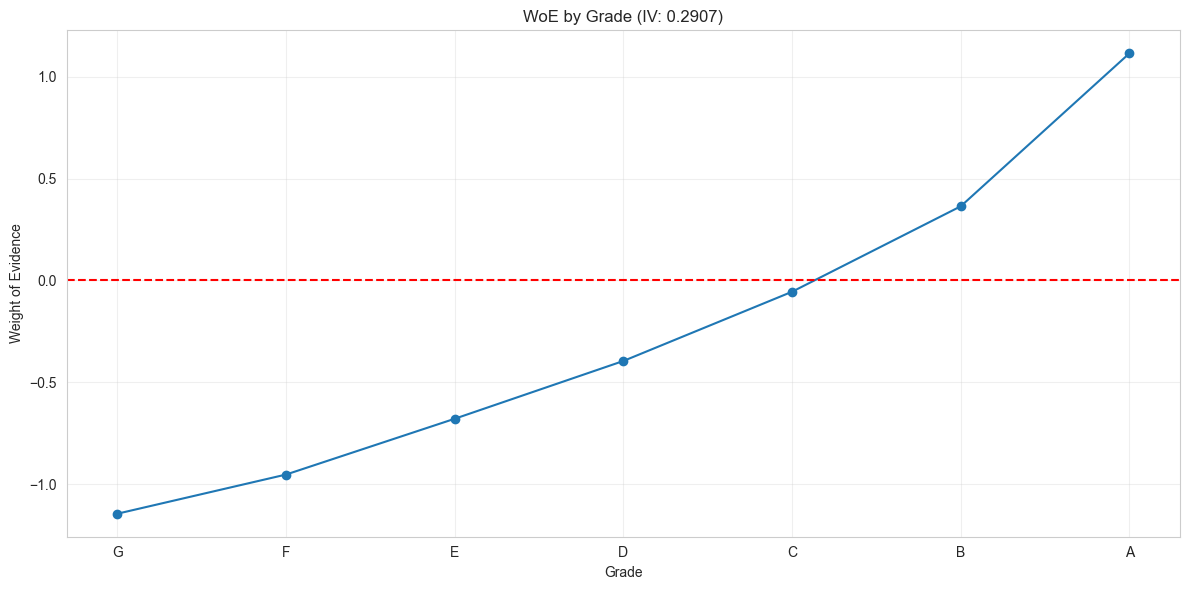

In [387]:
woe_grade, iv_grade = calc_woe(df_loans, 'grade')
print(f"IV: {iv_grade:.4f}")
print(woe_grade)

plt.figure(figsize=(12, 6))
plt.plot(woe_grade['grade'].astype(str), woe_grade['WoE'], marker='o', linestyle='-')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Grade')
plt.ylabel('Weight of Evidence')
plt.title(f'WoE by Grade (IV: {iv_grade:.4f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

IV: 0.0563
target_bad         annual_inc_bin   Good   Bad  Good%  Bad%     WoE  \
0             (1895.999, 22000.0]   8107  1519   1.95  2.98 -0.4234   
1              (22000.0, 26000.0]   8481  1456   2.04  2.86 -0.3360   
2              (35000.0, 37000.0]   7554  1284   1.82  2.52 -0.3261   
3              (26000.0, 30000.0]  13325  2220   3.21  4.36 -0.3059   
4              (31200.0, 34000.0]   9304  1532   2.24  3.01 -0.2942   
5              (34000.0, 35000.0]   7555  1241   1.82  2.43 -0.2919   
6              (30000.0, 31200.0]   2252   362   0.54  0.71 -0.2709   
7              (39000.0, 40000.0]  12246  1930   2.95  3.79 -0.2504   
8              (41600.0, 43000.0]   9849  1484   2.37  2.91 -0.2055   
9              (40000.0, 41600.0]   3851   561   0.93  1.10 -0.1722   
10             (43000.0, 45000.0]  14763  2149   3.55  4.22 -0.1709   
11             (47600.0, 49000.0]   8610  1253   2.07  2.46 -0.1708   
12             (50000.0, 50500.0]    773   112   0.19  0.22 -0.170

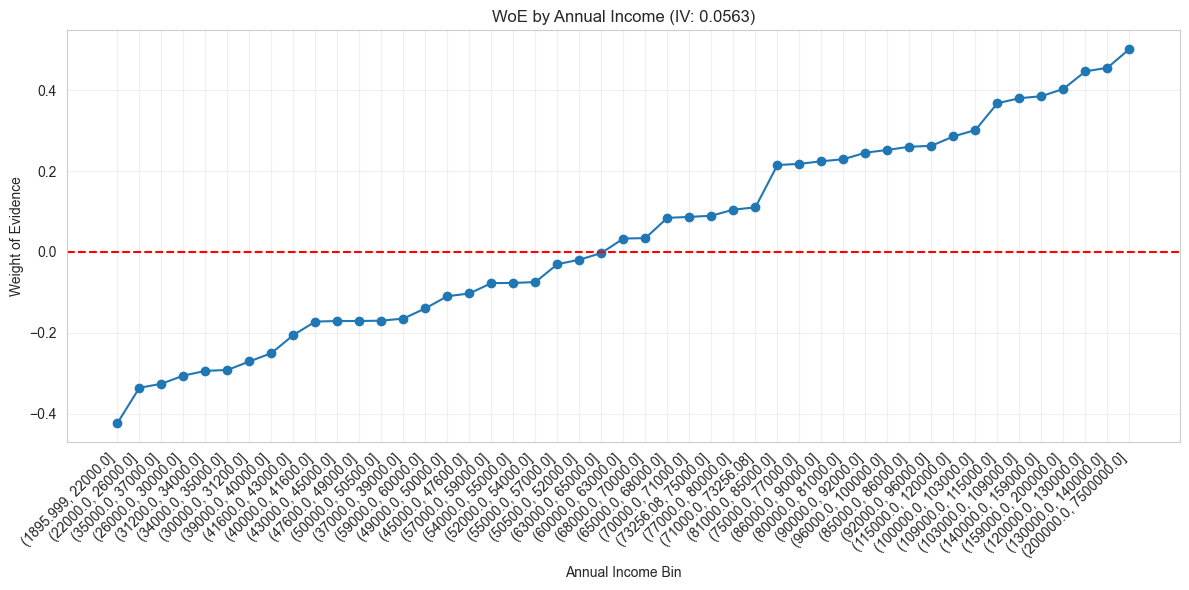

In [388]:
woe_annual_inc, iv_annual_inc = calc_woe(df_loans, 'annual_inc_bin')
print(f"IV: {iv_annual_inc:.4f}")
print(woe_annual_inc)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(woe_annual_inc['annual_inc_bin'].astype(str), woe_annual_inc['WoE'], marker='o', linestyle='-')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Annual Income Bin')
plt.ylabel('Weight of Evidence')
plt.title(f'WoE by Annual Income (IV: {iv_annual_inc:.4f})')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

IV: 0.0271
target_bad         dti_bin  Good   Bad  Good%  Bad%     WoE    IV_contrib
0           (28.95, 30.01]  7993  1262   1.92  2.48 -0.2523  1.412880e-03
1           (30.01, 31.58]  8073  1273   1.94  2.50 -0.2510  1.405600e-03
2           (31.58, 33.52]  8070  1243   1.94  2.44 -0.2275  1.137500e-03
3           (24.21, 24.83]  8081  1243   1.95  2.44 -0.2262  1.108380e-03
4            (27.12, 28.0]  8035  1234   1.93  2.42 -0.2246  1.100540e-03
5            (28.0, 28.95]  8133  1226   1.96  2.41 -0.2060  9.270000e-04
6           (26.29, 27.12]  8176  1228   1.97  2.41 -0.2024  8.905600e-04
7           (21.97, 22.51]  8175  1190   1.97  2.33 -0.1710  6.156000e-04
8           (25.53, 26.29]  8149  1183   1.96  2.32 -0.1684  6.062400e-04
9           (22.51, 23.06]  8147  1179   1.96  2.31 -0.1653  5.785500e-04
10          (33.52, 39.99]  8132  1175   1.96  2.31 -0.1637  5.729500e-04
11          (23.06, 23.62]  8104  1158   1.95  2.27 -0.1526  4.883200e-04
12          (24.83, 25.53] 

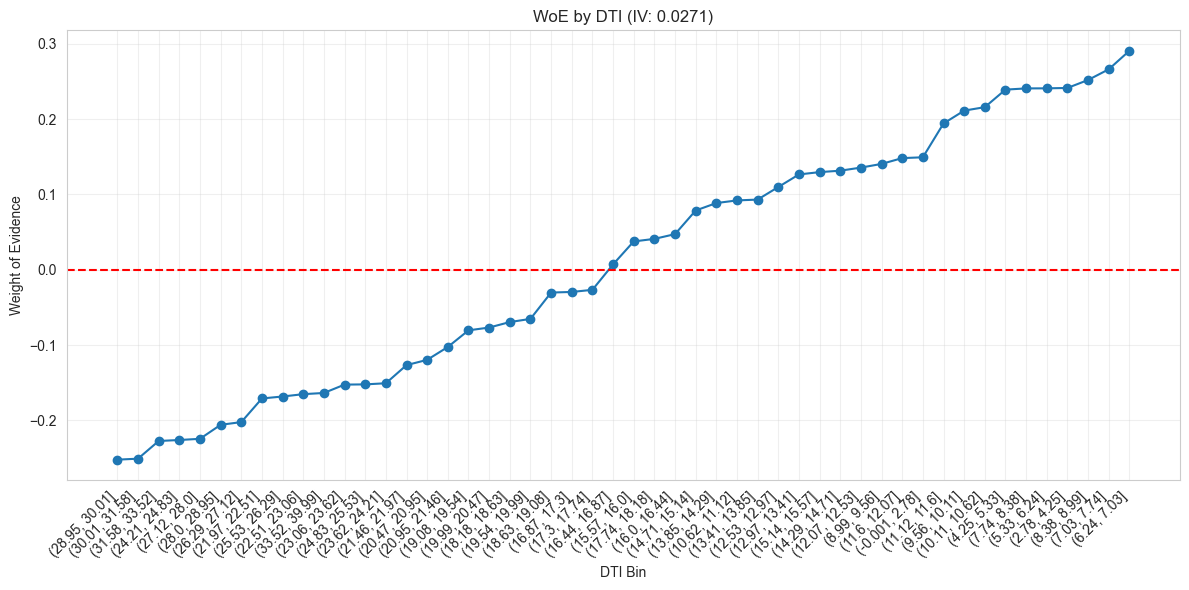

In [389]:
woe_dti, iv_dti = calc_woe(df_loans, 'dti_bin')
print(f"IV: {iv_dti:.4f}")
print(woe_dti)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(woe_dti['dti_bin'].astype(str), woe_dti['WoE'], marker='o', linestyle='-')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('DTI Bin')
plt.ylabel('Weight of Evidence')
plt.title(f'WoE by DTI (IV: {iv_dti:.4f})')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

IV: 0.0288
target_bad revol_util_bin  Good   Bad  Good%  Bad%     WoE    IV_contrib
0            (93.6, 96.3]  8069  1342   1.94  2.63 -0.3043  2.099670e-03
1           (96.3, 892.3]  7899  1301   1.90  2.55 -0.2946  1.914900e-03
2            (89.1, 91.3]  8123  1296   1.96  2.54 -0.2627  1.523660e-03
3            (91.3, 93.6]  7966  1244   1.92  2.44 -0.2413  1.254760e-03
4            (87.1, 89.1]  8078  1216   1.95  2.39 -0.2046  9.002400e-04
5            (85.2, 87.1]  8099  1209   1.95  2.37 -0.1962  8.240400e-04
6            (77.0, 78.5]  7859  1169   1.89  2.29 -0.1927  7.708000e-04
7            (80.1, 81.7]  7833  1149   1.89  2.25 -0.1788  6.436800e-04
8            (81.7, 83.4]  8077  1167   1.94  2.29 -0.1636  5.726000e-04
9            (67.0, 68.3]  7761  1094   1.87  2.15 -0.1390  3.892000e-04
10           (83.4, 85.2]  8271  1165   1.99  2.29 -0.1382  4.146000e-04
11           (75.5, 77.0]  8145  1140   1.96  2.24 -0.1318  3.690400e-04
12           (74.0, 75.5]  8211  1149   

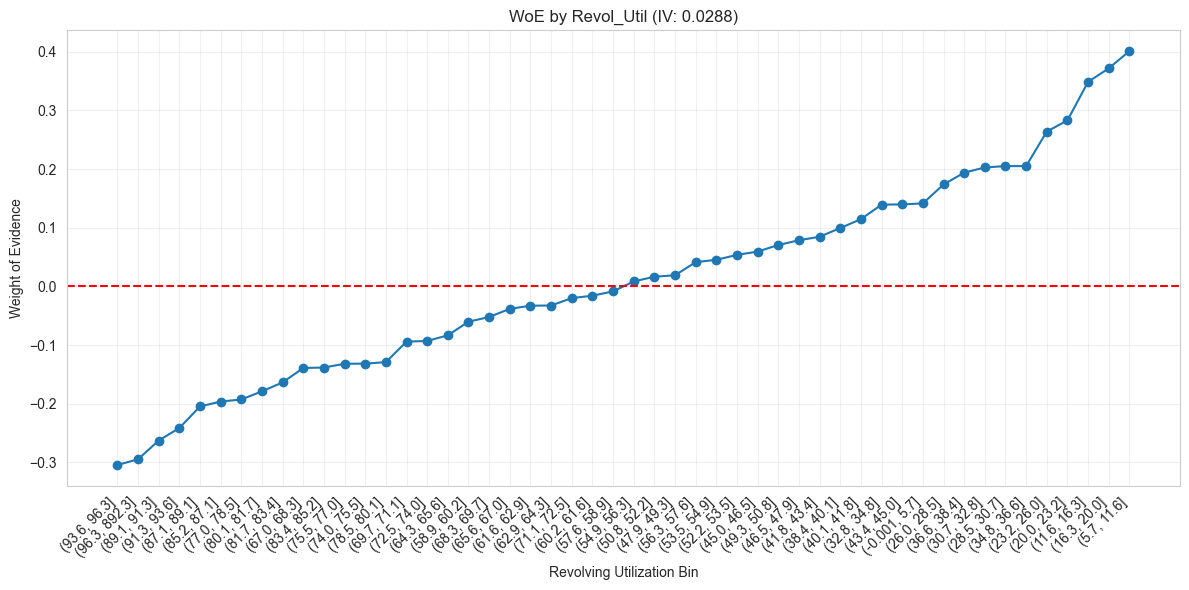

In [390]:
woe_revol_util, iv_revol_util = calc_woe(df_loans, 'revol_util_bin')
print(f"IV: {iv_revol_util:.4f}")
print(woe_revol_util)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(woe_revol_util['revol_util_bin'].astype(str), woe_revol_util['WoE'], marker='o', linestyle='-')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Revolving Utilization Bin')
plt.ylabel('Weight of Evidence')
plt.title(f'WoE by Revol_Util (IV: {iv_revol_util:.4f})')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

IV: 0.0518
target_bad inq_last_6mths_cat    Good    Bad  Good%   Bad%     WoE  IV_contrib
0                        20.0       0      1   0.00   0.00 -3.3673   -0.000000
1                        25.0       0      1   0.00   0.00 -3.3673   -0.000000
2                        32.0       0      1   0.00   0.00 -3.3673   -0.000000
3                        33.0       0      1   0.00   0.00 -3.3673   -0.000000
4                        14.0       1      5   0.00   0.01 -3.2958    0.000330
5                        15.0       4      5   0.00   0.01 -2.2842    0.000228
6                        18.0       2      2   0.00   0.00 -2.1001   -0.000000
7                        17.0       1      1   0.00   0.00 -1.9810   -0.000000
8                        12.0       9      6   0.00   0.01 -1.7165    0.000172
9                         8.0      76     46   0.02   0.09 -1.6007    0.001120
10                        9.0      32     18   0.01   0.04 -1.5377    0.000461
11                       13.0       4    

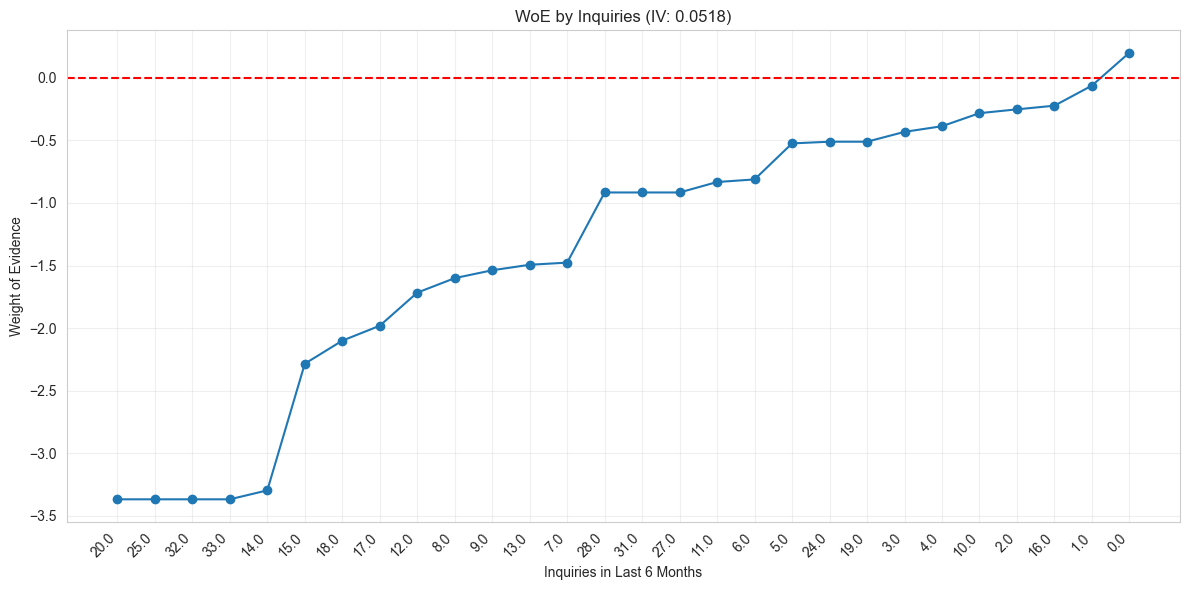

In [391]:
woe_inq, iv_inq = calc_woe(df_loans, 'inq_last_6mths_cat')
print(f"IV: {iv_inq:.4f}")
print(woe_inq)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(woe_inq['inq_last_6mths_cat'].astype(str), woe_inq['WoE'], marker='o', linestyle='-')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Inquiries in Last 6 Months')
plt.ylabel('Weight of Evidence')
plt.title(f'WoE by Inquiries (IV: {iv_inq:.4f})')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

IV: 0.0637
target_bad         tot_cur_bal_bin   Good    Bad  Good%   Bad%     WoE  \
0                (-0.001, 3707.44]  63249  11357  15.23  22.28 -0.3806   
1               (18856.0, 21156.0]   8200   1127   1.97   2.21 -0.1136   
2               (23439.0, 25783.0]   8203   1124   1.98   2.21 -0.1106   
3               (33512.6, 36482.0]   8217   1111   1.98   2.18 -0.0973   
4               (16598.0, 18856.0]   8227   1099   1.98   2.16 -0.0852   
5               (43404.0, 47620.0]   8229   1097   1.98   2.15 -0.0831   
6              (25783.0, 28231.24]   8230   1093   1.98   2.14 -0.0794   
7              (12004.48, 14319.0]   8235   1093   1.98   2.14 -0.0788   
8               (9582.0, 12004.48]   8237   1085   1.98   2.13 -0.0712   
9               (14319.0, 16598.0]   8247   1077   1.99   2.11 -0.0626   
10             (30759.92, 33512.6]   8258   1068   1.99   2.10 -0.0528   
11              (21156.0, 23439.0]   8260   1065   1.99   2.09 -0.0498   
12             (39706.96, 4

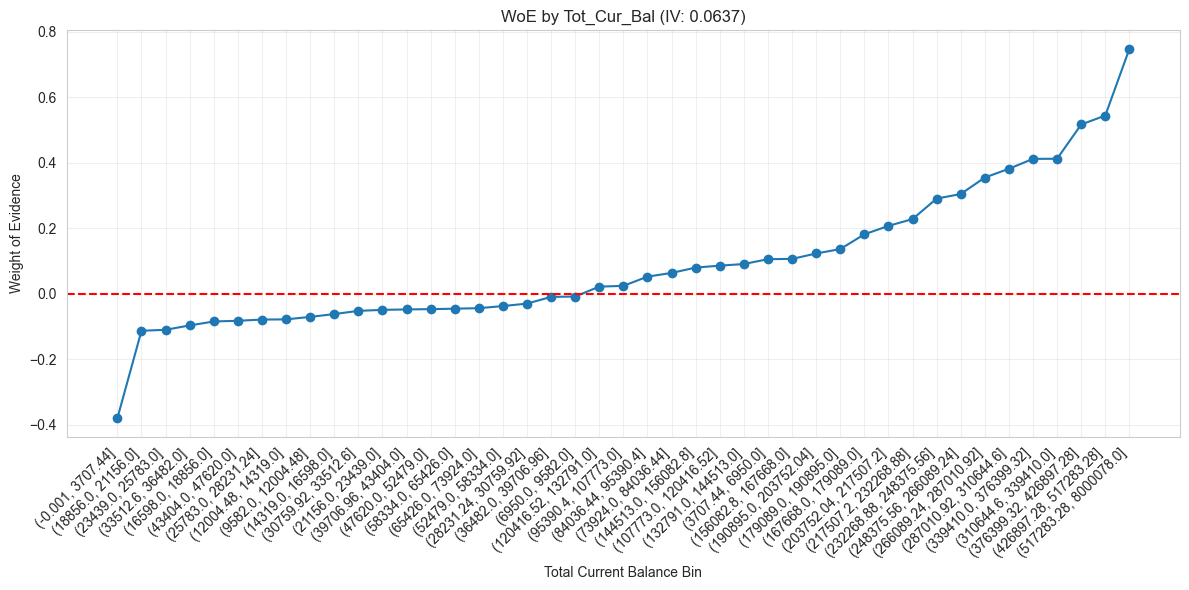

In [392]:
woe_tot_cur_bal, iv_tot_cur_bal = calc_woe(df_loans, 'tot_cur_bal_bin')
print(f"IV: {iv_tot_cur_bal:.4f}")
print(woe_tot_cur_bal)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(woe_tot_cur_bal['tot_cur_bal_bin'].astype(str), woe_tot_cur_bal['WoE'], marker='o', linestyle='-')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Total Current Balance Bin')
plt.ylabel('Weight of Evidence')
plt.title(f'WoE by Tot_Cur_Bal (IV: {iv_tot_cur_bal:.4f})')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

IV: 0.0458
target_bad   total_rev_hi_lim_bin   Good   Bad  Good%  Bad%     WoE  \
0                (-0.001, 3000.0]   8595  1479   2.07  2.90 -0.3383   
1                (4200.0, 5000.0]   8219  1272   1.98  2.50 -0.2323   
2               (9500.0, 10000.0]  10108  1497   2.43  2.94 -0.1883   
3                (3000.0, 4200.0]   7519  1105   1.81  2.17 -0.1807   
4              (15700.0, 16400.0]   8606  1263   2.07  2.48 -0.1792   
5              (19500.0, 20100.0]   8044  1178   1.94  2.31 -0.1771   
6              (17900.0, 18600.0]   7993  1163   1.92  2.28 -0.1706   
7                (7400.0, 8000.0]   8677  1259   2.09  2.47 -0.1678   
8              (14500.0, 15000.0]   8135  1169   1.96  2.29 -0.1581   
9                (5000.0, 6000.0]  10399  1481   2.50  2.91 -0.1491   
10             (15000.0, 15700.0]   7400  1048   1.78  2.06 -0.1436   
11               (8000.0, 8800.0]   8227  1138   1.98  2.23 -0.1201   
12               (6000.0, 6700.0]   6283   869   1.51  1.70 -0.120

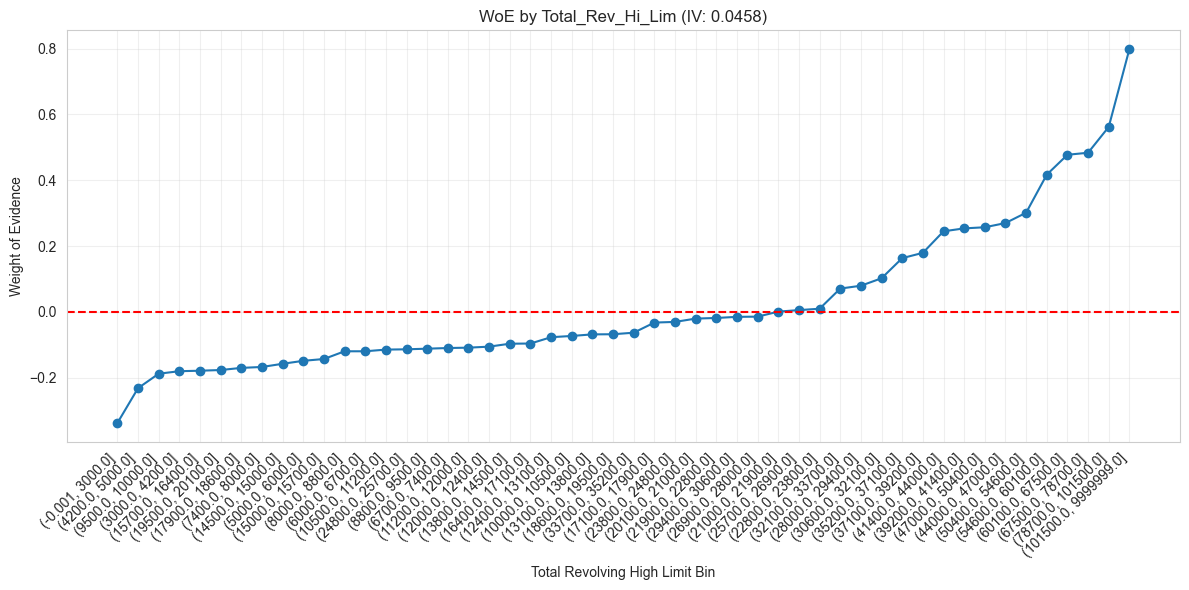

In [393]:
woe_total_rev_hi_lim, iv_total_rev_hi_lim = calc_woe(df_loans, 'total_rev_hi_lim_bin')
print(f"IV: {iv_total_rev_hi_lim:.4f}")
print(woe_total_rev_hi_lim)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(woe_total_rev_hi_lim['total_rev_hi_lim_bin'].astype(str), woe_total_rev_hi_lim['WoE'], marker='o', linestyle='-')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Total Revolving High Limit Bin')
plt.ylabel('Weight of Evidence')
plt.title(f'WoE by Total_Rev_Hi_Lim (IV: {iv_total_rev_hi_lim:.4f})')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

IV: 0.0389
target_bad term_int_cat    Good    Bad  Good%   Bad%     WoE  IV_contrib
0                    60  110174  18158  26.53  35.63 -0.2949    0.026836
1                    36  305143  32810  73.47  64.37  0.1322    0.012030


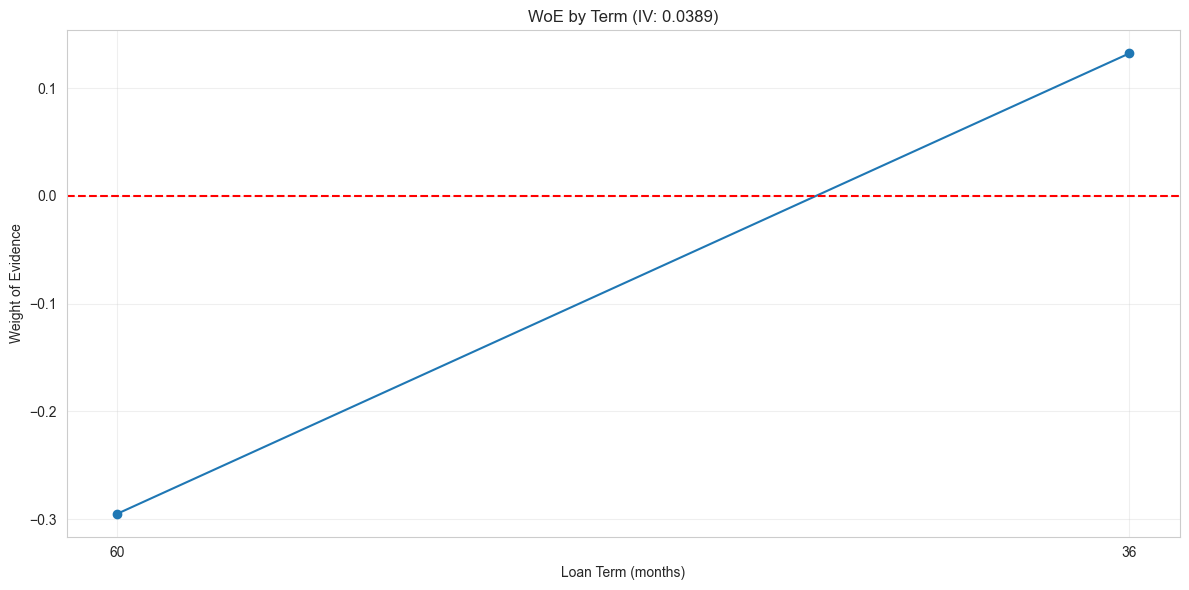

In [394]:
woe_term_int, iv_term_int = calc_woe(df_loans, 'term_int_cat')
print(f"IV: {iv_term_int:.4f}")
print(woe_term_int)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(woe_term_int['term_int_cat'].astype(str), woe_term_int['WoE'], marker='o', linestyle='-')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Loan Term (months)')
plt.ylabel('Weight of Evidence')
plt.title(f'WoE by Term (IV: {iv_term_int:.4f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

IV: 0.0370
target_bad             purpose    Good    Bad  Good%   Bad%     WoE  \
0               small_business    5500   1513   1.32   2.97 -0.8074   
1                  educational     334     88   0.08   0.17 -0.7685   
2             renewable_energy     297     54   0.07   0.11 -0.4008   
3                       moving    2537    457   0.61   0.90 -0.3846   
4                        house    1951    318   0.47   0.62 -0.2851   
5                        other   20421   3269   4.92   6.41 -0.2659   
6                      medical    3986    616   0.96   1.21 -0.2312   
7                      wedding    2058    285   0.50   0.56 -0.1223   
8                     vacation    2194    293   0.53   0.57 -0.0859   
9           debt_consolidation  243126  31069  58.54  60.96 -0.0405   
10            home_improvement   23932   2605   5.76   5.11  0.1198   
11              major_purchase    8889    939   2.14   1.84  0.1494   
12                         car    4916    481   1.18   0.94  0.225

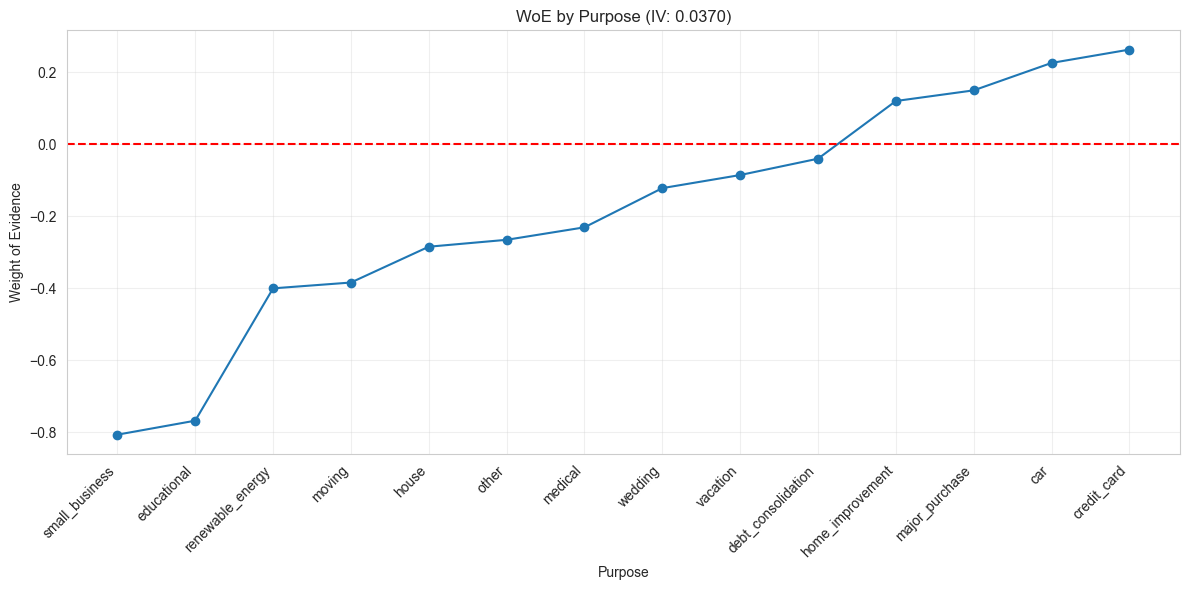

In [395]:
woe_purpose, iv_purpose = calc_woe(df_loans, 'purpose')
print(f"IV: {iv_purpose:.4f}")
print(woe_purpose)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(woe_purpose['purpose'].astype(str), woe_purpose['WoE'], marker='o', linestyle='-')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Purpose')
plt.ylabel('Weight of Evidence')
plt.title(f'WoE by Purpose (IV: {iv_purpose:.4f})')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

IV: 0.0217
target_bad home_ownership    Good    Bad  Good%   Bad%     WoE  IV_contrib
0                     ANY       1      0   0.00   0.00 -0.9163   -0.000000
1                   OTHER     144     38   0.03   0.07 -0.7745    0.000310
2                    NONE      42      8   0.01   0.02 -0.4930    0.000049
3                    RENT  164706  23767  39.66  46.63 -0.1620    0.011291
4                     OWN   37189   4515   8.95   8.86  0.0107    0.000010
5                MORTGAGE  213235  22640  51.34  44.42  0.1448    0.010020


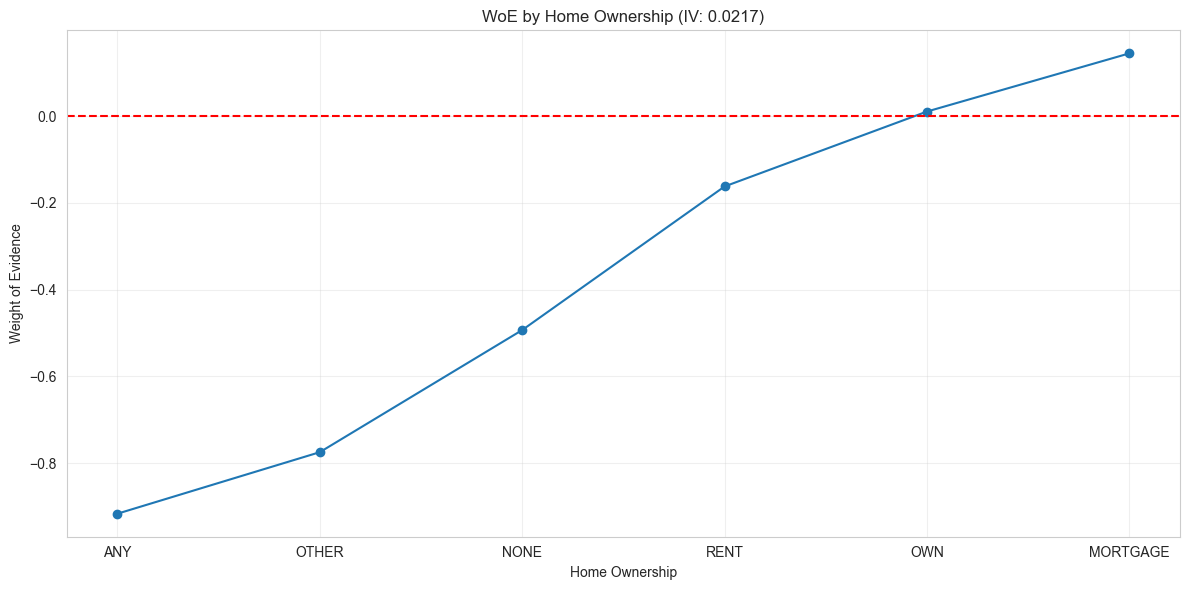

In [396]:
woe_ho, iv_ho = calc_woe(df_loans, 'home_ownership')
print(f"IV: {iv_ho:.4f}")
print(woe_ho)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(woe_ho['home_ownership'].astype(str), woe_ho['WoE'], marker='o', linestyle='-')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Home Ownership')
plt.ylabel('Weight of Evidence')
plt.title(f'WoE by Home Ownership (IV: {iv_ho:.4f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

IV: 0.0208
target_bad verification_status    Good    Bad  Good%   Bad%     WoE  \
0                     Verified  146650  21405  35.31  42.00 -0.1734   
1              Source Verified  134376  15617  32.36  30.64  0.0544   
2                 Not Verified  134291  13946  32.33  27.36  0.1670   

target_bad  IV_contrib  
0             0.011600  
1             0.000936  
2             0.008300  


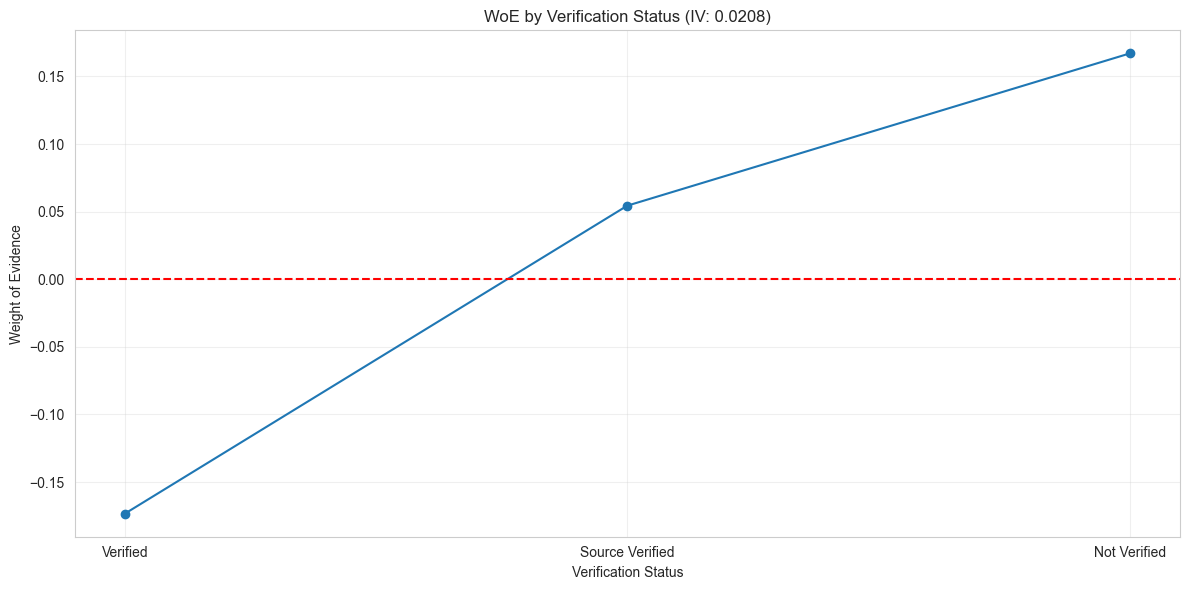

In [397]:
woe_vs, iv_vs = calc_woe(df_loans, 'verification_status')
print(f"IV: {iv_vs:.4f}")
print(woe_vs)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(woe_vs['verification_status'].astype(str), woe_vs['WoE'], marker='o', linestyle='-')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Verification Status')
plt.ylabel('Weight of Evidence')
plt.title(f'WoE by Verification Status (IV: {iv_vs:.4f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

IV: 0.0248
target_bad initial_list_status    Good    Bad  Good%   Bad%     WoE  \
0                            f  266551  36454  64.18  71.52 -0.1083   
1                            w  148766  14514  35.82  28.48  0.2294   

target_bad  IV_contrib  
0             0.007949  
1             0.016838  


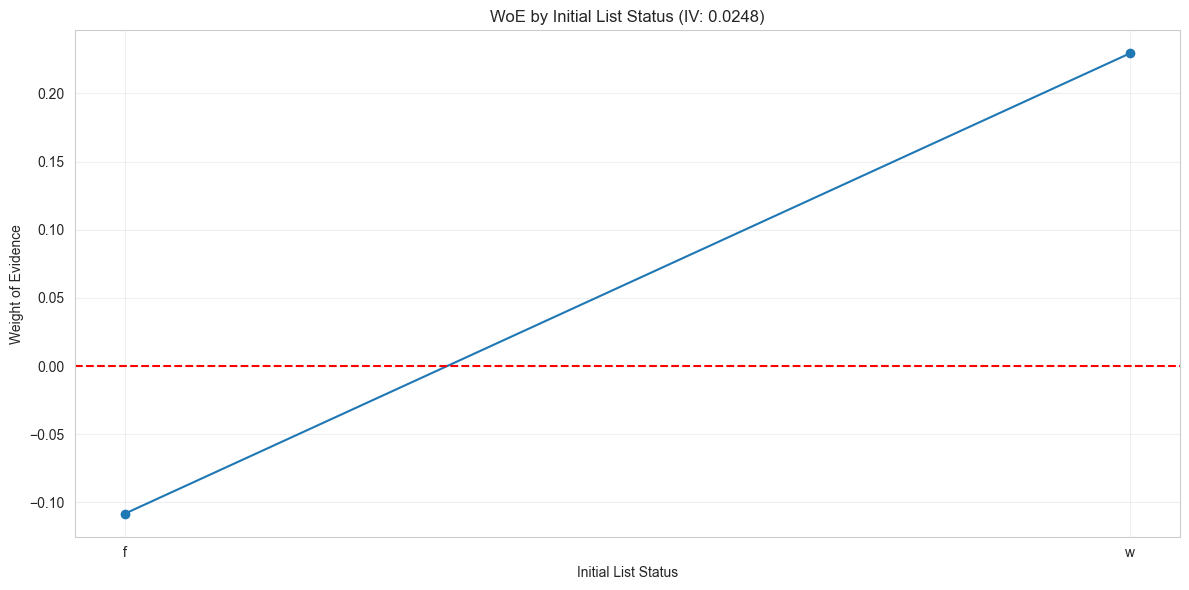

In [398]:
woe_ils, iv_ils = calc_woe(df_loans, 'initial_list_status')
print(f"IV: {iv_ils:.4f}")
print(woe_ils)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(woe_ils['initial_list_status'].astype(str), woe_ils['WoE'], marker='o', linestyle='-')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Initial List Status')
plt.ylabel('Weight of Evidence')
plt.title(f'WoE by Initial List Status (IV: {iv_ils:.4f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [399]:
print("\nBefore merging:")
print(df_loans['purpose'].value_counts())

purpose_merge_map = {
    'small_business': 'OTHER',
    'educational': 'OTHER',
    'renewable_energy': 'OTHER',
    'moving': 'OTHER',
    'house': 'OTHER',
    'other': 'OTHER',
    'medical': 'OTHER',
    'wedding': 'OTHER',
    'vacation': 'OTHER',
    'debt_consolidation': 'debt_consolidation',
    'home_improvement': 'home_improvement',
    'major_purchase': 'major_purchase',
    'car': 'car',
    'credit_card': 'credit_card'
}

df_loans['purpose_merged'] = df_loans['purpose'].map(purpose_merge_map)
print(df_loans['purpose_merged'].value_counts())

woe_pu_merged, iv_pu_merged = calc_woe(df_loans, 'purpose_merged')
print(f"\nIV after merging: {iv_ho_merged:.4f}")
print(woe_pu_merged)


Before merging:
purpose
debt_consolidation    274195
credit_card           104157
home_improvement       26537
other                  23690
major_purchase          9828
small_business          7013
car                     5397
medical                 4602
moving                  2994
vacation                2487
wedding                 2343
house                   2269
educational              422
renewable_energy         351
Name: count, dtype: int64
purpose_merged
debt_consolidation    274195
credit_card           104157
OTHER                  46171
home_improvement       26537
major_purchase          9828
car                     5397
Name: count, dtype: int64

IV after merging: 0.0215
target_bad      purpose_merged    Good    Bad  Good%   Bad%     WoE  \
0                        OTHER   39278   6893   9.46  13.52 -0.3577   
1           debt_consolidation  243126  31069  58.54  60.96 -0.0405   
2             home_improvement   23932   2605   5.76   5.11  0.1198   
3               ma

In [400]:
print("\nBefore merging:")
print(df_loans['home_ownership'].value_counts())

df_loans['home_ownership_merged'] = df_loans['home_ownership'].replace({
    'ANY': 'RENT',
    'NONE': 'RENT',
    'OTHER': 'RENT'
})

print("\nAfter merging:")
print(df_loans['home_ownership_merged'].value_counts())

woe_ho_merged, iv_ho_merged = calc_woe(df_loans, 'home_ownership_merged')
print(f"\nIV after merging: {iv_ho_merged:.4f}")
print(woe_ho_merged)


Before merging:
home_ownership
MORTGAGE    235875
RENT        188473
OWN          41704
OTHER          182
NONE            50
ANY              1
Name: count, dtype: int64

After merging:
home_ownership_merged
MORTGAGE    235875
RENT        188706
OWN          41704
Name: count, dtype: int64

IV after merging: 0.0215
target_bad home_ownership_merged    Good    Bad  Good%   Bad%     WoE  \
0                           RENT  164893  23813  39.70  46.72 -0.1628   
1                            OWN   37189   4515   8.95   8.86  0.0107   
2                       MORTGAGE  213235  22640  51.34  44.42  0.1448   

target_bad  IV_contrib  
0             0.011429  
1             0.000010  
2             0.010020  


In [401]:
print("\nBefore merging:")
print(df_loans['inq_last_6mths'].value_counts().sort_index())

def merge_inq(x):
    if x == 0:
        return '0'
    elif x <= 2:
        return '1-2'
    elif x <= 6:
        return '3-6'
    else:
        return '7+'

df_loans['inq_last_6mths_merged'] = df_loans['inq_last_6mths'].apply(merge_inq)

print("\nAfter merging:")
print(df_loans['inq_last_6mths_merged'].value_counts())

woe_inq_merged, iv_inq_merged = calc_woe(df_loans, 'inq_last_6mths_merged')
print(f"\nIV after merging: {iv_inq_merged:.4f}")
print(woe_inq_merged)


Before merging:
inq_last_6mths
0.0     241527
1.0     130148
2.0      57825
3.0      25126
4.0       7241
5.0       2768
6.0       1188
7.0        195
8.0        122
9.0         50
10.0        24
11.0        15
12.0        15
13.0         6
14.0         6
15.0         9
16.0         3
17.0         2
18.0         4
19.0         2
20.0         1
24.0         2
25.0         1
27.0         1
28.0         1
31.0         1
32.0         1
33.0         1
Name: count, dtype: int64

After merging:
inq_last_6mths_merged
0      241527
1-2    187973
3-6     36323
7+        462
Name: count, dtype: int64

IV after merging: 0.0477
target_bad inq_last_6mths_merged    Good    Bad  Good%   Bad%     WoE  \
0                             7+     299    163   0.07   0.32 -1.4928   
1                            3-6   30488   5835   7.34  11.45 -0.4444   
2                            1-2  165046  22927  39.74  44.98 -0.1239   
3                              0  219484  22043  52.85  43.25  0.2004   

target_bad

In [402]:
bin_breaks = {
    'int_rate': [5.419, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0, 22.0, 24.0, 26.06],
    'annual_inc': [0, 30000, 45000, 60000, 80000, 100000, 130000, 160000, 7500000],
    'dti': [0, 5, 8, 11, 14, 18, 22, 28, 40],
    'revol_util': [0, 20, 40, 55, 70, 80, 90, 95, 100, 9999],
    'tot_cur_bal': [0, 10000, 25000, 50000, 100000, 200000, 400000, 800000, 8000078],
    'total_rev_hi_lim': [0, 5000, 10000, 20000, 40000, 70000, 100000, 150000, 9999999]
}

for col, breaks in bin_breaks.items():
    df_loans[f'{col}_bin_final'] = pd.cut(df_loans[col], bins=breaks, include_lowest=True, duplicates='drop')
    print(f"{col}: {len(df_loans[f'{col}_bin_final'].unique())} bins created")

int_rate: 10 bins created
annual_inc: 8 bins created
dti: 8 bins created
revol_util: 9 bins created
tot_cur_bal: 8 bins created
total_rev_hi_lim: 8 bins created


In [403]:
final_vars = [
    'int_rate_bin_final',
    'grade',
    'home_ownership_merged',
    'annual_inc_bin_final',
    'verification_status',
    'purpose_merged',
    'dti_bin_final',
    'inq_last_6mths_merged',
    'revol_util_bin_final',
    'initial_list_status',
    'tot_cur_bal_bin_final',
    'total_rev_hi_lim_bin_final',
    'term_int',
    'target_bad'
]

df_final = df_loans[final_vars].copy()

df_final.columns = [
    'int_rate_bin',
    'grade',
    'home_ownership',
    'annual_inc_bin',
    'verification_status',
    'purpose',
    'dti_bin',
    'inq_last_6mths',
    'revol_util_bin',
    'initial_list_status',
    'tot_cur_bal_bin',
    'total_rev_hi_lim_bin',
    'term_int',
    'target_bad'
]

print(f"Final dataset shape: {df_final.shape}")
print(f"Columns ({len(df_final.columns)}):")
print(df_final.columns.tolist())
print(f"\nMissing values: {df_final.isnull().sum().sum()}")

Final dataset shape: (466285, 14)
Columns (14):
['int_rate_bin', 'grade', 'home_ownership', 'annual_inc_bin', 'verification_status', 'purpose', 'dti_bin', 'inq_last_6mths', 'revol_util_bin', 'initial_list_status', 'tot_cur_bal_bin', 'total_rev_hi_lim_bin', 'term_int', 'target_bad']

Missing values: 0


In [404]:
final_vars_check = ['int_rate_bin', 'grade', 'home_ownership', 'annual_inc_bin', 
                    'verification_status', 'purpose', 'dti_bin', 'inq_last_6mths',
                    'revol_util_bin', 'initial_list_status', 'tot_cur_bal_bin',
                    'total_rev_hi_lim_bin', 'term_int']

for var in final_vars_check:
    woe_df, iv = calc_woe(df_final, var)
    print(f"\n{var.upper()} (IV: {iv:.4f})")
    print(woe_df.to_string(index=False))


INT_RATE_BIN (IV: 0.3199)
            int_rate_bin  Good   Bad  Good%  Bad%     WoE  IV_contrib
           (24.0, 26.06]  6767  2079   1.63  4.08 -0.9178    0.022486
            (22.0, 24.0]  9374  2827   2.26  5.55 -0.8992    0.029584
            (20.0, 22.0] 15238  3876   3.67  7.60 -0.7289    0.028646
            (18.0, 20.0] 32330  6956   7.78 13.65 -0.5615    0.032960
            (16.0, 18.0] 44781  8017  10.78 15.73 -0.3777    0.018696
            (14.0, 16.0] 73004 10033  17.58 19.68 -0.1132    0.002377
            (12.0, 14.0] 80363  8501  19.35 16.68  0.1485    0.003965
            (10.0, 12.0] 61817  4689  14.88  9.20  0.4810    0.027321
             (8.0, 10.0] 39801  2147   9.58  4.21  0.8218    0.044131
(5.417999999999999, 8.0] 51842  1843  12.48  3.62  1.2387    0.109749

GRADE (IV: 0.2907)
grade   Good   Bad  Good%  Bad%     WoE  IV_contrib
    G   2398   924   0.58  1.81 -1.1445    0.014077
    F  10037  3192   2.42  6.26 -0.9523    0.036568
    E  28793  6964   6.93 1

In [405]:
def get_woe_map(df, feature, target='target_bad'):
    woe_df, _ = calc_woe(df, feature, target)
    return dict(zip(woe_df[feature], woe_df['WoE']))

woe_vars = ['int_rate_bin', 'grade', 'home_ownership', 'annual_inc_bin', 
            'verification_status', 'purpose', 'dti_bin', 'inq_last_6mths',
            'revol_util_bin', 'initial_list_status', 'tot_cur_bal_bin',
            'total_rev_hi_lim_bin', 'term_int']

woe_maps = {}
for var in woe_vars:
    woe_maps[var] = get_woe_map(df_final, var)
    print(f"{var}: {len(woe_maps[var])} categories")

df_woe = df_final.copy()
for var in woe_vars:
    df_woe[f'{var}_woe'] = df_woe[var].map(woe_maps[var])

woe_columns = [f'{var}_woe' for var in woe_vars]
X = df_woe[woe_columns].copy()
y = df_woe['target_bad']

print(f"   Features: {X.shape[1]}")
print(f"   Rows: {X.shape[0]:,}")
print(f"   Target shape: {y.shape}")
print(f"   Missing values: {X.isnull().sum().sum()}")

int_rate_bin: 10 categories
grade: 7 categories
home_ownership: 3 categories
annual_inc_bin: 8 categories
verification_status: 3 categories
purpose: 6 categories
dti_bin: 8 categories
inq_last_6mths: 4 categories
revol_util_bin: 9 categories
initial_list_status: 2 categories
tot_cur_bal_bin: 8 categories
total_rev_hi_lim_bin: 8 categories
term_int: 2 categories
   Features: 13
   Rows: 466,285
   Target shape: (466285,)
   Missing values: 0


In [406]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42,
    stratify=y
)

print(f"\nTraining set: {X_train.shape[0]:,} rows")
print(f"  Default rate: {y_train.mean():.2%}")
print(f"Test set: {X_test.shape[0]:,} rows")
print(f"  Default rate: {y_test.mean():.2%}")


Training set: 326,399 rows
  Default rate: 10.93%
Test set: 139,886 rows
  Default rate: 10.93%


In [407]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

model = sm.Logit(y_train, X_train_const).fit(method='bfgs', maxiter=1000, disp=False)

In [408]:
print(model.summary())

                           Logit Regression Results                           
Dep. Variable:             target_bad   No. Observations:               326399
Model:                          Logit   Df Residuals:                   326385
Method:                           MLE   Df Model:                           13
Date:                Wed, 22 Jul 2026   Pseudo R-squ.:                 0.05952
Time:                        22:55:38   Log-Likelihood:            -1.0593e+05
converged:                       True   LL-Null:                   -1.1263e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -2.1028      0.006   -353.794      0.000      -2.114      -2.091
int_rate_bin_woe            -0.8044      0.031    -25.974      0.000      -0.865      -0.

In [409]:
X_train_refit = X_train.drop(columns=['grade_woe'])
X_test_refit = X_test.drop(columns=['grade_woe'])

X_train_refit_const = sm.add_constant(X_train_refit)
X_test_refit_const = sm.add_constant(X_test_refit)

model_refit = sm.Logit(y_train, X_train_refit_const).fit(method='bfgs', maxiter=1000, disp=False)

print(model_refit.summary())

                           Logit Regression Results                           
Dep. Variable:             target_bad   No. Observations:               326399
Model:                          Logit   Df Residuals:                   326386
Method:                           MLE   Df Model:                           12
Date:                Wed, 22 Jul 2026   Pseudo R-squ.:                 0.05952
Time:                        22:55:46   Log-Likelihood:            -1.0593e+05
converged:                       True   LL-Null:                   -1.1263e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -2.1028      0.006   -353.789      0.000      -2.114      -2.091
int_rate_bin_woe            -0.8230      0.013    -61.264      0.000      -0.849      -0.

In [410]:
from sklearn.metrics import roc_auc_score, roc_curve

y_pred_proba = model_refit.predict(X_test_refit_const)

auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC: {auc:.4f}")

gini = 2 * auc - 1
print(f"Gini: {gini:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
ks = max(tpr - fpr)
print(f"KS: {ks:.4f}")

AUC: 0.6822
Gini: 0.3644
KS: 0.2647


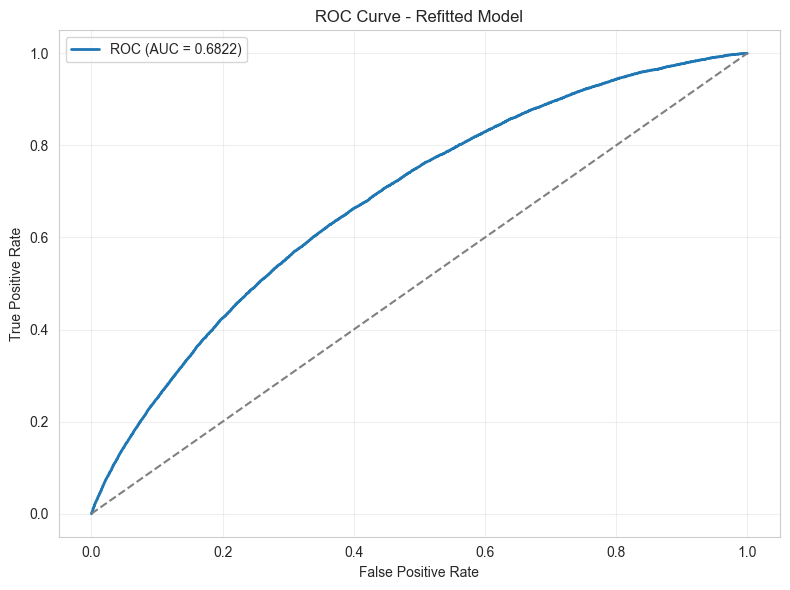

In [411]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Refitted Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [412]:
coefficients = model_refit.params.drop('const')

logits_train = model_refit.predict(X_train_refit_const)

min_logit = logits_train.min()
max_logit = logits_train.max()

print(f"Logit range: {min_logit:.4f} to {max_logit:.4f}")

Logit range: 0.0088 to 0.5397


In [413]:
min_score = 300
max_score = 850
factor = (max_score - min_score) / (max_logit - min_logit)
print(f"Scaling factor: {factor:.4f}")

Scaling factor: 1035.9268


In [414]:
scorecard_rows = []

for var in coefficients.index:
    original_var = var.replace('_woe', '')
    
    woe_map = woe_maps[original_var]
    beta = coefficients[var]
    
    for category, woe_value in woe_map.items():
        points = beta * woe_value * factor
        scorecard_rows.append({
            'Variable': original_var,
            'Category': str(category),
            'WoE': round(woe_value, 4),
            'Beta': round(beta, 4),
            'Points': round(points, 2)
        })

scorecard_df = pd.DataFrame(scorecard_rows)

print(f"\nScorecard created: {len(scorecard_df)} rows")
print(f"Variables: {scorecard_df['Variable'].nunique()}")

print("\nSample (first 20 rows):")
print(scorecard_df.head(20).to_string(index=False))

scorecard_df.to_csv('scorecard_final.csv', index=False)
print("\n✅ Scorecard saved to 'scorecard_final.csv'")


Scorecard created: 71 rows
Variables: 12

Sample (first 20 rows):
      Variable                 Category     WoE    Beta   Points
  int_rate_bin            (24.0, 26.06] -0.9178 -0.8230   782.49
  int_rate_bin             (22.0, 24.0] -0.8992 -0.8230   766.63
  int_rate_bin             (20.0, 22.0] -0.7289 -0.8230   621.44
  int_rate_bin             (18.0, 20.0] -0.5615 -0.8230   478.72
  int_rate_bin             (16.0, 18.0] -0.3777 -0.8230   322.02
  int_rate_bin             (14.0, 16.0] -0.1132 -0.8230    96.51
  int_rate_bin             (12.0, 14.0]  0.1485 -0.8230  -126.61
  int_rate_bin             (10.0, 12.0]  0.4810 -0.8230  -410.09
  int_rate_bin              (8.0, 10.0]  0.8218 -0.8230  -700.64
  int_rate_bin (5.417999999999999, 8.0]  1.2387 -0.8230 -1056.08
home_ownership                     RENT -0.1628 -0.1351    22.78
home_ownership                      OWN  0.0107 -0.1351    -1.50
home_ownership                 MORTGAGE  0.1448 -0.1351   -20.26
annual_inc_bin        (

In [415]:
scores_train = factor * logits_train + (max_score - factor * max_logit)

print(f"\nScore Statistics (Training Set):")
print(f"  Min: {scores_train.min():.1f}")
print(f"  Max: {scores_train.max():.1f}")
print(f"  Mean: {scores_train.mean():.1f}")
print(f"  Median: {scores_train.median():.1f}")


Score Statistics (Training Set):
  Min: 300.0
  Max: 850.0
  Mean: 404.1
  Median: 392.3


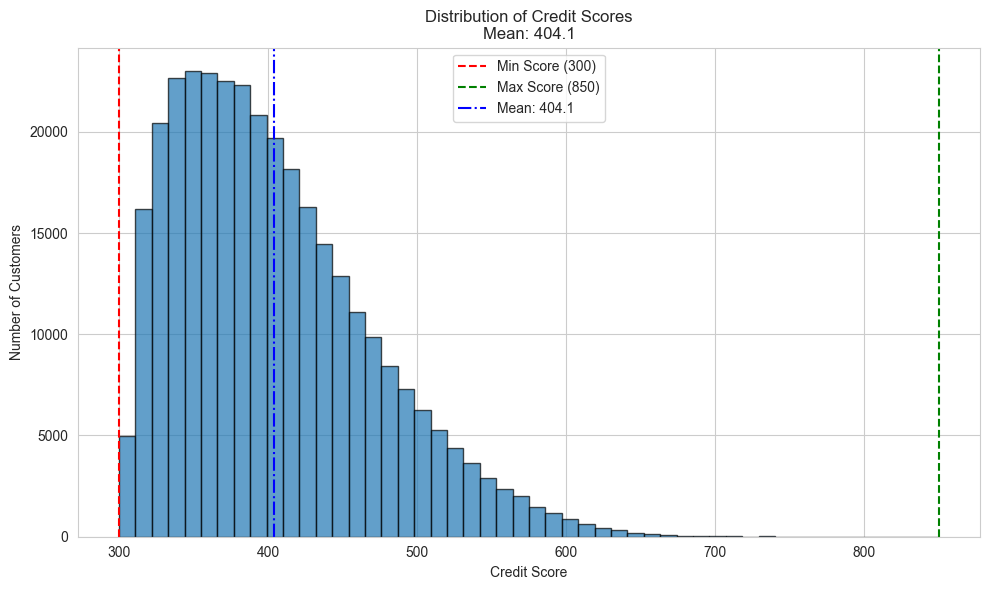

In [416]:
plt.figure(figsize=(10, 6))
plt.hist(scores_train, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=300, color='red', linestyle='--', label='Min Score (300)')
plt.axvline(x=850, color='green', linestyle='--', label='Max Score (850)')
plt.axvline(x=scores_train.mean(), color='blue', linestyle='-.', label=f'Mean: {scores_train.mean():.1f}')
plt.xlabel('Credit Score')
plt.ylabel('Number of Customers')
plt.title(f'Distribution of Credit Scores\nMean: {scores_train.mean():.1f}')
plt.legend()
plt.tight_layout()
plt.show()

In [417]:
from scipy.stats import chi2

def hosmer_lemeshow(y_true, y_pred_proba, n_bins=10):
    df_hl = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred_proba})
    df_hl = df_hl.sort_values('y_pred')
    df_hl['bin'] = pd.qcut(df_hl['y_pred'], q=n_bins, labels=False, duplicates='drop')
    
    grouped = df_hl.groupby('bin').agg(
        n_obs=('y_true', 'count'),
        n_bad=('y_true', 'sum'),
        mean_pred=('y_pred', 'mean')
    ).reset_index()
    
    grouped['n_good'] = grouped['n_obs'] - grouped['n_bad']
    grouped['exp_bad'] = grouped['n_obs'] * grouped['mean_pred']
    grouped['exp_good'] = grouped['n_obs'] * (1 - grouped['mean_pred'])
    
    chi2_stat = ((grouped['n_bad'] - grouped['exp_bad'])**2 / grouped['exp_bad']).sum() + \
                ((grouped['n_good'] - grouped['exp_good'])**2 / grouped['exp_good']).sum()
    p_value = 1 - chi2.cdf(chi2_stat, n_bins - 2)
    
    print(f"Chi-Square: {chi2_stat:.4f}")
    print(f"P-Value: {p_value:.4f}")
    
    if p_value > 0.05:
        print("✅ PASS: Model is well-calibrated")
    else:
        print("❌ FAIL: Model is miscalibrated")
    
    print("\nCalibration by Decile:")
    print(grouped.round(4).to_string(index=False))
    return chi2_stat, p_value, grouped

y_pred_proba_test = model_refit.predict(X_test_refit_const)
hl_chi2, hl_p, hl_table = hosmer_lemeshow(y_test, y_pred_proba_test)

Chi-Square: 6.8145
P-Value: 0.5568
✅ PASS: Model is well-calibrated

Calibration by Decile:
 bin  n_obs  n_bad  mean_pred  n_good   exp_bad   exp_good
   0  13989    389     0.0265   13600  370.2215 13618.7785
   1  13989    593     0.0438   13396  612.2656 13376.7344
   2  13988    838     0.0590   13150  825.2095 13162.7905
   3  13989   1073     0.0741   12916 1036.6650 12952.3350
   4  13988   1255     0.0896   12733 1252.7083 12735.2917
   5  13989   1432     0.1062   12557 1485.2613 12503.7387
   6  13988   1713     0.1247   12275 1744.0599 12243.9401
   7  13989   2057     0.1473   11932 2060.5138 11928.4862
   8  13989   2540     0.1786   11449 2499.0878 11489.9122
   9  13988   3400     0.2426   10588 3392.7993 10595.2007


2015 data shape: (421094, 12)

2015 Score Statistics:
  Min: 299.0
  Max: 720.5
  Mean: 381.2
  Median: 367.7

PSI Total: 0.130084

Interpretation:
Moderate shift. Investigate further.


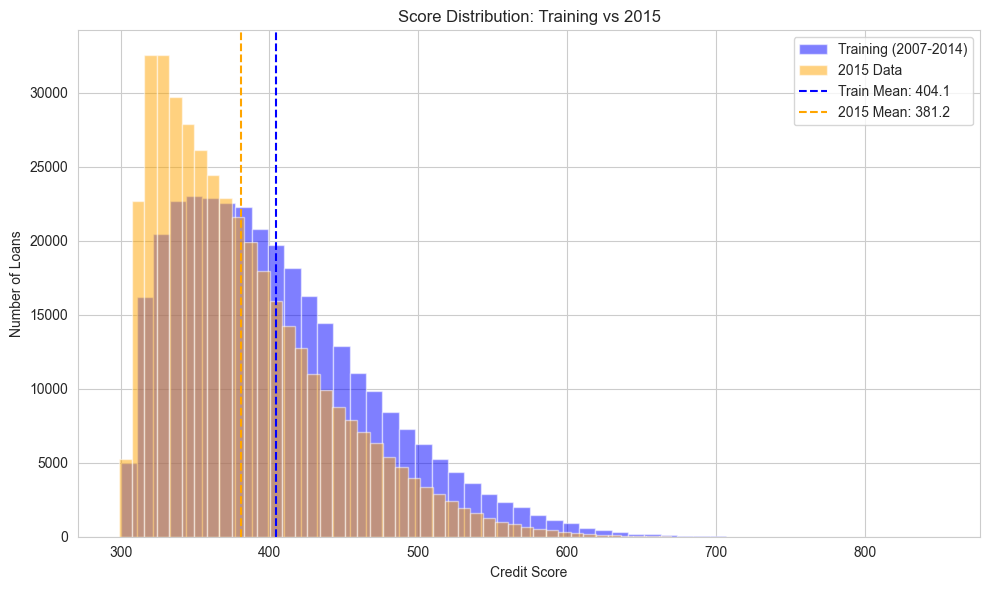

In [418]:
def prepare_2015_woe(df_2015):
    """Apply same transformations to 2015 data."""
    df = df_2015.copy()
    
    drop_cols = [
        'id', 'member_id', 'url', 'desc', 'title', 'zip_code', 'emp_title',
        'policy_code', 'pymnt_plan', 'sub_grade',
        'issue_d', 'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d',
        'funded_amnt_inv', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
        'annual_inc_joint', 'dti_joint', 'verification_status_joint',
        'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il',
        'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc',
        'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m'
    ]
    df.drop(columns=drop_cols, inplace=True, errors='ignore')
    
    df['term_int'] = df['term'].str.replace(' months', '').astype(int)
    EMP_MAP = {
        '10+ years': 10, '9 years': 9, '8 years': 8, '7 years': 7,
        '6 years': 6, '5 years': 5, '4 years': 4, '3 years': 3,
        '2 years': 2, '1 year': 1, '< 1 year': 0, 'n/a': 0
    }
    df['emp_length_int'] = df['emp_length'].map(EMP_MAP).fillna(0).astype(int)
    
    df['earliest_cr_line_date'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%y', errors='coerce')
    ref_date = pd.to_datetime('2017-12-01')
    df['mths_since_earliest'] = ((ref_date - df['earliest_cr_line_date']).dt.days / 30.44).round(0).fillna(0).astype(int)
    df['mths_since_earliest'] = df['mths_since_earliest'].clip(lower=0)
    df.drop(columns=['earliest_cr_line', 'earliest_cr_line_date'], inplace=True, errors='ignore')
    
    for col in ['mths_since_last_delinq', 'mths_since_last_record', 'mths_since_last_major_derog', 'collections_12_mths_ex_med']:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    
    bureau_cols = ['delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'total_acc', 'acc_now_delinq']
    for col in bureau_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    
    df['annual_inc'] = df['annual_inc'].fillna(df['annual_inc'].median())
    df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())
    df['total_rev_hi_lim'] = df['total_rev_hi_lim'].fillna(df['funded_amnt'])
    df['tot_coll_amt'] = df['tot_coll_amt'].fillna(0)
    df['tot_cur_bal'] = df['tot_cur_bal'].fillna(0)
    
    df.drop(columns=['term', 'emp_length', 'loan_status'], inplace=True, errors='ignore')
    
    bin_breaks = {
        'int_rate': [5.419, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0, 22.0, 24.0, 26.06],
        'annual_inc': [0, 30000, 45000, 60000, 80000, 100000, 130000, 160000, 7500000],
        'dti': [0, 5, 8, 11, 14, 18, 22, 28, 40],
        'revol_util': [0, 20, 40, 55, 70, 80, 90, 95, 100, 9999],
        'tot_cur_bal': [0, 10000, 25000, 50000, 100000, 200000, 400000, 800000, 8000078],
        'total_rev_hi_lim': [0, 5000, 10000, 20000, 40000, 70000, 100000, 150000, 9999999]
    }
    for col, breaks in bin_breaks.items():
        if col in df.columns:
            df[f'{col}_bin'] = pd.cut(df[col], bins=breaks, include_lowest=True, duplicates='drop')
    
    if 'inq_last_6mths' in df.columns:
        def merge_inq(x):
            if x == 0:
                return '0'
            elif x <= 2:
                return '1-2'
            elif x <= 6:
                return '3-6'
            else:
                return '7+'
        df['inq_last_6mths'] = df['inq_last_6mths'].apply(merge_inq)
    
    PURPOSE_MAP = {
        'small_business': 'OTHER', 'educational': 'OTHER', 'renewable_energy': 'OTHER',
        'moving': 'OTHER', 'house': 'OTHER', 'other': 'OTHER', 'medical': 'OTHER',
        'wedding': 'OTHER', 'vacation': 'OTHER',
        'debt_consolidation': 'debt_consolidation', 'home_improvement': 'home_improvement',
        'major_purchase': 'major_purchase', 'car': 'car', 'credit_card': 'credit_card'
    }
    if 'purpose' in df.columns:
        df['purpose'] = df['purpose'].map(PURPOSE_MAP)
    
    if 'home_ownership' in df.columns:
        df['home_ownership'] = df['home_ownership'].replace({'ANY': 'RENT', 'NONE': 'RENT', 'OTHER': 'RENT'})
    
    for var, woe_map in woe_maps.items():
        if var in df.columns:
            df[f'{var}_woe'] = df[var].map(woe_map)
    
    woe_cols = [f'{var}_woe' for var in woe_maps.keys() if f'{var}_woe' in df.columns]
    return df[woe_cols]

df_2015_woe = prepare_2015_woe(df_loans1)

missing_cols = set(X_train_refit.columns) - set(df_2015_woe.columns)
for col in missing_cols:
    df_2015_woe[col] = 0

df_2015_woe = df_2015_woe[X_train_refit.columns]

print(f"2015 data shape: {df_2015_woe.shape}")

X_2015_const = sm.add_constant(df_2015_woe)
scores_2015 = factor * model_refit.predict(X_2015_const) + (max_score - factor * max_logit)

print(f"\n2015 Score Statistics:")
print(f"  Min: {scores_2015.min():.1f}")
print(f"  Max: {scores_2015.max():.1f}")
print(f"  Mean: {scores_2015.mean():.1f}")
print(f"  Median: {scores_2015.median():.1f}")

def calculate_psi(expected, actual, bins=10):
    min_val = min(expected.min(), actual.min())
    max_val = max(expected.max(), actual.max())
    bin_edges = np.linspace(min_val, max_val, bins + 1)
    
    exp_counts, _ = np.histogram(expected, bins=bin_edges)
    act_counts, _ = np.histogram(actual, bins=bin_edges)
    
    exp_prop = np.where(exp_counts / exp_counts.sum() == 0, 0.0001, exp_counts / exp_counts.sum())
    act_prop = np.where(act_counts / act_counts.sum() == 0, 0.0001, act_counts / act_counts.sum())
    
    return ((act_prop - exp_prop) * np.log(act_prop / exp_prop)).sum()

psi_total = calculate_psi(scores_train, scores_2015)

print(f"\nPSI Total: {psi_total:.6f}")
print("\nInterpretation:")
if psi_total < 0.10:
    print("No significant change. Model is stable.")
elif psi_total < 0.25:
    print("Moderate shift. Investigate further.")
else:
    print("Significant shift. Model needs recalibration.")

plt.figure(figsize=(10, 6))
plt.hist(scores_train, bins=50, alpha=0.5, label='Training (2007-2014)', color='blue')
plt.hist(scores_2015, bins=50, alpha=0.5, label='2015 Data', color='orange')
plt.axvline(x=scores_train.mean(), color='blue', linestyle='--', label=f'Train Mean: {scores_train.mean():.1f}')
plt.axvline(x=scores_2015.mean(), color='orange', linestyle='--', label=f'2015 Mean: {scores_2015.mean():.1f}')
plt.xlabel('Credit Score')
plt.ylabel('Number of Loans')
plt.title('Score Distribution: Training vs 2015')
plt.legend()
plt.tight_layout()
plt.show()

In [419]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, r2_score, mean_absolute_error
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [420]:
df = pd.read_csv('3.1 loan_data_2007_2014.csv', low_memory=False)

print(f"Raw data shape: {df.shape}")

Raw data shape: (466285, 75)


In [421]:
bad_statuses = [
    'Charged Off', 
    'Default', 
    'Does not meet the credit policy. Status:Charged Off', 
    'Late (31-120 days)'
]

df_defaults = df[df['loan_status'].isin(bad_statuses)].copy()

print(f"Defaulted loans: {len(df_defaults):,}")

Defaulted loans: 50,968


In [422]:
print(f"\nRecovery columns available:")
print(df_defaults[['funded_amnt', 'recoveries', 'collection_recovery_fee', 'total_rec_prncp']].head())


Recovery columns available:
    funded_amnt  recoveries  collection_recovery_fee  total_rec_prncp
1          2500      117.08                   1.1100           456.46
8          5600      189.06                   2.0900           162.02
9          5375      269.29                   2.5200           673.48
12         9000      444.30                   4.1600          1256.14
14        10000      645.10                   6.3145          5433.47


In [423]:
df_defaults['recovery_rate'] = df_defaults['recoveries'] / df_defaults['funded_amnt']
df_defaults['recovery_rate'] = df_defaults['recovery_rate'].clip(0, 1)
df_defaults['recovery_indicator'] = (df_defaults['recovery_rate'] > 0).astype(int)

print(f"Recovery Indicator:")
print(df_defaults['recovery_indicator'].value_counts())
print(f"  Percentage with recovery > 0: {df_defaults['recovery_indicator'].mean():.2%}")

print(f"\nRecovery Rate Statistics (where recovery > 0):")
print(df_defaults[df_defaults['recovery_indicator'] == 1]['recovery_rate'].describe())

Recovery Indicator:
recovery_indicator
0    26597
1    24371
Name: count, dtype: int64
  Percentage with recovery > 0: 47.82%

Recovery Rate Statistics (where recovery > 0):
count    24371.000000
mean         0.107810
std          0.095105
min          0.000036
25%          0.050709
50%          0.105384
75%          0.134812
max          1.000000
Name: recovery_rate, dtype: float64


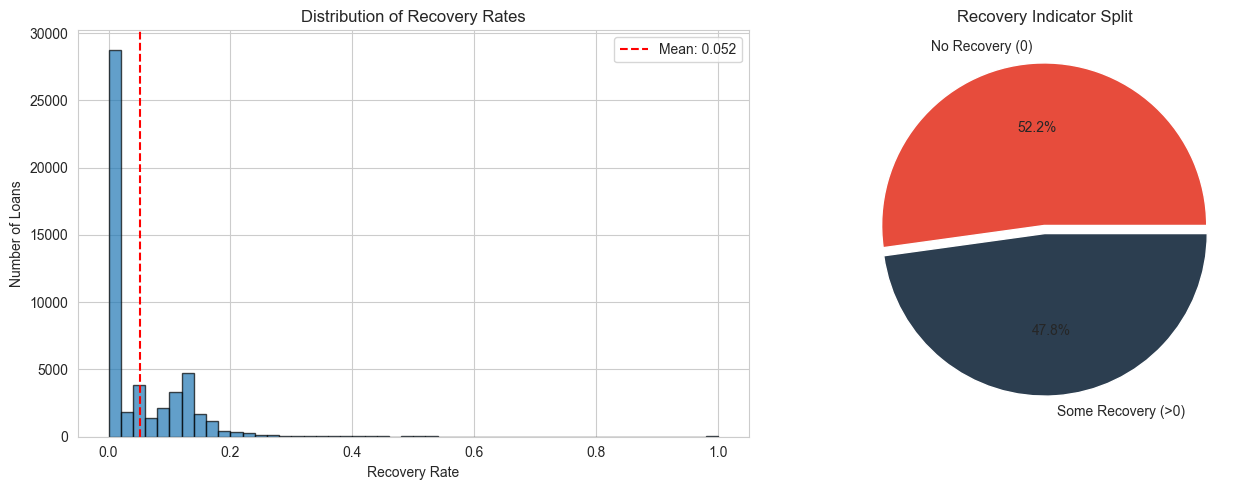

In [424]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_defaults['recovery_rate'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=df_defaults['recovery_rate'].mean(), color='red', linestyle='--', 
                label=f'Mean: {df_defaults["recovery_rate"].mean():.3f}')
axes[0].set_xlabel('Recovery Rate')
axes[0].set_ylabel('Number of Loans')
axes[0].set_title('Distribution of Recovery Rates')
axes[0].legend()

indicator_counts = df_defaults['recovery_indicator'].value_counts()
axes[1].pie(indicator_counts, 
            labels=['No Recovery (0)', 'Some Recovery (>0)'], 
            autopct='%1.1f%%', 
            colors=['#e74c3c', '#2c3e50'], 
            explode=(0.05, 0))
axes[1].set_title('Recovery Indicator Split')

plt.tight_layout()
plt.show()

In [425]:
df_defaults['term_int'] = df_defaults['term'].str.replace(' months', '').astype(int)

emp_map = {
    '10+ years': 10, '9 years': 9, '8 years': 8, '7 years': 7,
    '6 years': 6, '5 years': 5, '4 years': 4, '3 years': 3,
    '2 years': 2, '1 year': 1, '< 1 year': 0, 'n/a': 0
}
df_defaults['emp_length_int'] = df_defaults['emp_length'].map(emp_map).fillna(0).astype(int)

df_defaults['earliest_cr_line_date'] = pd.to_datetime(df_defaults['earliest_cr_line'], format='%b-%y', errors='coerce')
ref_date = pd.to_datetime('2017-12-01')
df_defaults['mths_since_earliest'] = ((ref_date - df_defaults['earliest_cr_line_date']).dt.days / 30.44).round(0).fillna(0).astype(int)
df_defaults['mths_since_earliest'] = df_defaults['mths_since_earliest'].clip(lower=0)

zero_cols = ['mths_since_last_delinq', 'mths_since_last_record', 'mths_since_last_major_derog', 'collections_12_mths_ex_med']
for col in zero_cols:
    df_defaults[col] = df_defaults[col].fillna(0)

bureau_cols = ['delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'total_acc', 'acc_now_delinq']
for col in bureau_cols:
    df_defaults[col] = df_defaults[col].fillna(0)

df_defaults['annual_inc'] = df_defaults['annual_inc'].fillna(df_defaults['annual_inc'].median())
df_defaults['revol_util'] = df_defaults['revol_util'].fillna(df_defaults['revol_util'].median())

df_defaults['total_rev_hi_lim'] = df_defaults['total_rev_hi_lim'].fillna(df_defaults['funded_amnt'])

df_defaults['tot_coll_amt'] = df_defaults['tot_coll_amt'].fillna(0)
df_defaults['tot_cur_bal'] = df_defaults['tot_cur_bal'].fillna(0)

df_defaults.drop(columns=['earliest_cr_line', 'earliest_cr_line_date', 'term', 'emp_length', 'loan_status'], 
                 inplace=True, errors='ignore')

print(f"Missing values remaining: {df_defaults.isnull().sum().sum()}")
print(f"Defaulted loans shape: {df_defaults.shape}")

Missing values remaining: 947028
Defaulted loans shape: (50968, 76)


In [426]:
bin_breaks = {
    'int_rate': [5.419, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0, 22.0, 24.0, 26.06],
    'annual_inc': [0, 30000, 45000, 60000, 80000, 100000, 130000, 160000, 7500000],
    'dti': [0, 5, 8, 11, 14, 18, 22, 28, 40],
    'revol_util': [0, 20, 40, 55, 70, 80, 90, 95, 100, 9999],
    'tot_cur_bal': [0, 10000, 25000, 50000, 100000, 200000, 400000, 800000, 8000078],
    'total_rev_hi_lim': [0, 5000, 10000, 20000, 40000, 70000, 100000, 150000, 9999999]
}

for col, breaks in bin_breaks.items():
    if col in df_defaults.columns:
        df_defaults[f'{col}_bin'] = pd.cut(df_defaults[col], bins=breaks, include_lowest=True, duplicates='drop')
        print(f"{col}_bin created")

purpose_map = {
    'small_business': 'OTHER', 'educational': 'OTHER', 'renewable_energy': 'OTHER',
    'moving': 'OTHER', 'house': 'OTHER', 'other': 'OTHER', 'medical': 'OTHER',
    'wedding': 'OTHER', 'vacation': 'OTHER',
    'debt_consolidation': 'debt_consolidation', 'home_improvement': 'home_improvement',
    'major_purchase': 'major_purchase', 'car': 'car', 'credit_card': 'credit_card'
}
df_defaults['purpose'] = df_defaults['purpose'].map(purpose_map)

df_defaults['home_ownership'] = df_defaults['home_ownership'].replace({
    'ANY': 'RENT', 'NONE': 'RENT', 'OTHER': 'RENT'
})

def merge_inq(x):
    if x == 0:
        return '0'
    elif x <= 2:
        return '1-2'
    elif x <= 6:
        return '3-6'
    else:
        return '7+'
df_defaults['inq_last_6mths'] = df_defaults['inq_last_6mths'].apply(merge_inq)


try:
    print(f"Using existing woe_maps from PD (contains {len(woe_maps)} variables)")
except NameError:
    print("woe_maps not found. Creating new ones...")
    
    def get_woe_from_data(df, feature, target='recovery_indicator'):
        woe_df, _ = calc_woe(df, feature, target)
        return dict(zip(woe_df[feature], woe_df['WoE']))
    
    encode_vars = ['grade', 'home_ownership', 'verification_status', 'purpose', 
                   'int_rate_bin', 'annual_inc_bin', 'dti_bin', 'revol_util_bin',
                   'tot_cur_bal_bin', 'total_rev_hi_lim_bin', 'inq_last_6mths', 
                   'initial_list_status', 'term_int']
    
    woe_maps = {}
    for var in encode_vars:
        if var in df_defaults.columns:
            woe_maps[var] = get_woe_from_data(df_defaults, var)
            print(f"  ✓ {var}: {len(woe_maps[var])} categories")

for var, woe_map in woe_maps.items():
    if var in df_defaults.columns:
        df_defaults[f'{var}_woe'] = df_defaults[var].map(woe_map)
        if df_defaults[f'{var}_woe'].isnull().any():
            df_defaults[f'{var}_woe'] = df_defaults[f'{var}_woe'].fillna(0)
            print(f"{var}_woe applied (with 0 filling)")

woe_cols = [f'{var}_woe' for var in woe_maps.keys() if f'{var}_woe' in df_defaults.columns]
if 'grade_woe' in woe_cols:
    woe_cols.remove('grade_woe')

print(f"Features: {len(woe_cols)}")
print(woe_cols)

int_rate_bin created
annual_inc_bin created
dti_bin created
revol_util_bin created
tot_cur_bal_bin created
total_rev_hi_lim_bin created
Using existing woe_maps from PD (contains 13 variables)
Features: 12
['int_rate_bin_woe', 'home_ownership_woe', 'annual_inc_bin_woe', 'verification_status_woe', 'purpose_woe', 'dti_bin_woe', 'inq_last_6mths_woe', 'revol_util_bin_woe', 'initial_list_status_woe', 'tot_cur_bal_bin_woe', 'total_rev_hi_lim_bin_woe', 'term_int_woe']


In [427]:
X_lgd = df_defaults[woe_cols].copy()
y_ind = df_defaults['recovery_indicator']
y_rate = df_defaults['recovery_rate']

print(f"Features: {X_lgd.shape[1]}")
print(f"Rows: {X_lgd.shape[0]:,}")
print(f"Missing values in X: {X_lgd.isnull().sum().sum()}")

X_train, X_test, y_train_ind, y_test_ind = train_test_split(
    X_lgd, y_ind, test_size=0.30, random_state=42, stratify=y_ind
)

print(f"Stage 1 - Training: {X_train.shape[0]:,}")
print(f"Stage 1 - Test: {X_test.shape[0]:,}")
print(f"Stage 1 - Default rate: {y_train_ind.mean():.2%}")

Features: 12
Rows: 50,968
Missing values in X: 0
Stage 1 - Training: 35,677
Stage 1 - Test: 15,291
Stage 1 - Default rate: 47.82%


In [428]:
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

model_l1 = sm.Logit(y_train_ind, X_train_const).fit(method='bfgs', maxiter=1000, disp=False)

print(model_l1.summary())

                           Logit Regression Results                           
Dep. Variable:     recovery_indicator   No. Observations:                35677
Model:                          Logit   Df Residuals:                    35664
Method:                           MLE   Df Model:                           12
Date:                Wed, 22 Jul 2026   Pseudo R-squ.:                 0.06971
Time:                        22:56:17   Log-Likelihood:                -22974.
converged:                       True   LL-Null:                       -24695.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -0.2074      0.012    -17.267      0.000      -0.231      -0.184
int_rate_bin_woe            -0.1704      0.026     -6.518      0.000      -0.222      -0.

In [429]:
drop_vars = ['total_rev_hi_lim_bin_woe', 'term_int_woe']
X_train_refit = X_train.drop(columns=drop_vars)
X_test_refit = X_test.drop(columns=drop_vars)

X_train_refit_const = sm.add_constant(X_train_refit)
X_test_refit_const = sm.add_constant(X_test_refit)

model_l1_refit = sm.Logit(y_train_ind, X_train_refit_const).fit(method='bfgs', maxiter=1000, disp=False)

print(model_l1_refit.summary())

                           Logit Regression Results                           
Dep. Variable:     recovery_indicator   No. Observations:                35677
Model:                          Logit   Df Residuals:                    35666
Method:                           MLE   Df Model:                           10
Date:                Wed, 22 Jul 2026   Pseudo R-squ.:                 0.06962
Time:                        22:56:25   Log-Likelihood:                -22976.
converged:                       True   LL-Null:                       -24695.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -0.2070      0.012    -17.237      0.000      -0.230      -0.183
int_rate_bin_woe           -0.1888      0.024     -7.948      0.000      -0.235      -0.142


In [430]:
y_pred_proba_l1_refit = model_l1_refit.predict(X_test_refit_const)
auc_l1_refit = roc_auc_score(y_test_ind, y_pred_proba_l1_refit)
gini_l1_refit = 2 * auc_l1_refit - 1
fpr_l1_refit, tpr_l1_refit, _ = roc_curve(y_test_ind, y_pred_proba_l1_refit)
ks_l1_refit = max(tpr_l1_refit - fpr_l1_refit)

print(f"AUC:  {auc_l1_refit:.4f}")
print(f"Gini: {gini_l1_refit:.4f}")
print(f"KS:   {ks_l1_refit:.4f}")

AUC:  0.6766
Gini: 0.3533
KS:   0.2632


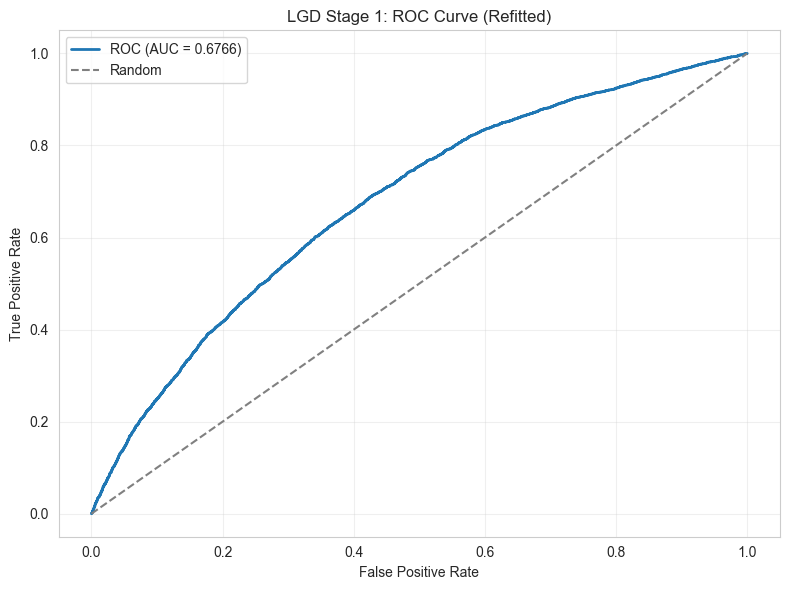

In [431]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_l1_refit, tpr_l1_refit, linewidth=2, label=f'ROC (AUC = {auc_l1_refit:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LGD Stage 1: ROC Curve (Refitted)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [432]:
indices_train_stage2 = y_train_ind[y_train_ind == 1].index
indices_test_stage2 = y_test_ind[y_test_ind == 1].index

X_train_stage2 = X_train_refit.loc[indices_train_stage2]
y_train_stage2 = y_rate.loc[indices_train_stage2]

X_test_stage2 = X_test_refit.loc[indices_test_stage2]
y_test_stage2 = y_rate.loc[indices_test_stage2]

print(f"Stage 2 - Training: {X_train_stage2.shape[0]:,} loans with recovery > 0")
print(f"Stage 2 - Test: {X_test_stage2.shape[0]:,} loans with recovery > 0")

Stage 2 - Training: 17,059 loans with recovery > 0
Stage 2 - Test: 7,312 loans with recovery > 0


In [433]:
X_train_stage2_const = sm.add_constant(X_train_stage2)
X_test_stage2_const = sm.add_constant(X_test_stage2)

model_l2 = sm.OLS(y_train_stage2, X_train_stage2_const).fit()

print(model_l2.summary())

                            OLS Regression Results                            
Dep. Variable:          recovery_rate   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     108.9
Date:                Wed, 22 Jul 2026   Prob (F-statistic):          1.51e-220
Time:                        22:56:28   Log-Likelihood:                 16110.
No. Observations:               17059   AIC:                        -3.220e+04
Df Residuals:                   17048   BIC:                        -3.211e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [434]:
drop_vars_l2 = ['home_ownership_woe', 'inq_last_6mths_woe', 'purpose_woe', 'verification_status_woe']

X_train_stage2_refit = X_train_stage2.drop(columns=drop_vars_l2)
X_test_stage2_refit = X_test_stage2.drop(columns=drop_vars_l2)

X_train_stage2_refit_const = sm.add_constant(X_train_stage2_refit)
X_test_stage2_refit_const = sm.add_constant(X_test_stage2_refit)

model_l2_refit = sm.OLS(y_train_stage2, X_train_stage2_refit_const).fit()

print(model_l2_refit.summary())

                            OLS Regression Results                            
Dep. Variable:          recovery_rate   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     180.3
Date:                Wed, 22 Jul 2026   Prob (F-statistic):          2.35e-223
Time:                        22:56:29   Log-Likelihood:                 16107.
No. Observations:               17059   AIC:                        -3.220e+04
Df Residuals:                   17052   BIC:                        -3.214e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [435]:
probs_stage1_all = model_l1_refit.predict(X_test_refit_const)

X_test_stage2_for_all = X_test_refit.drop(columns=drop_vars_l2)
X_test_stage2_for_all_const = sm.add_constant(X_test_stage2_for_all)
preds_stage2_all = model_l2_refit.predict(X_test_stage2_for_all_const)

final_pred_recovery = probs_stage1_all * preds_stage2_all

actual_recovery_all = y_rate.loc[X_test_refit.index]

lgd_actual = 1 - actual_recovery_all
lgd_predicted = 1 - final_pred_recovery

print(f"  R² (Actual Recovery vs Predicted): {r2_score(actual_recovery_all, final_pred_recovery):.4f}")
print(f"  MAE (Recovery): {mean_absolute_error(actual_recovery_all, final_pred_recovery):.4f}")

  R² (Actual Recovery vs Predicted): 0.0208
  MAE (Recovery): 0.0572


In [436]:
print(f"  Actual LGD Mean: {lgd_actual.mean():.4f}")
print(f"  Predicted LGD Mean: {lgd_predicted.mean():.4f}")
print(f"  Actual LGD Median: {lgd_actual.median():.4f}")
print(f"  Predicted LGD Median: {lgd_predicted.median():.4f}")

  Actual LGD Mean: 0.9492
  Predicted LGD Mean: 0.9482
  Actual LGD Median: 1.0000
  Predicted LGD Median: 0.9479


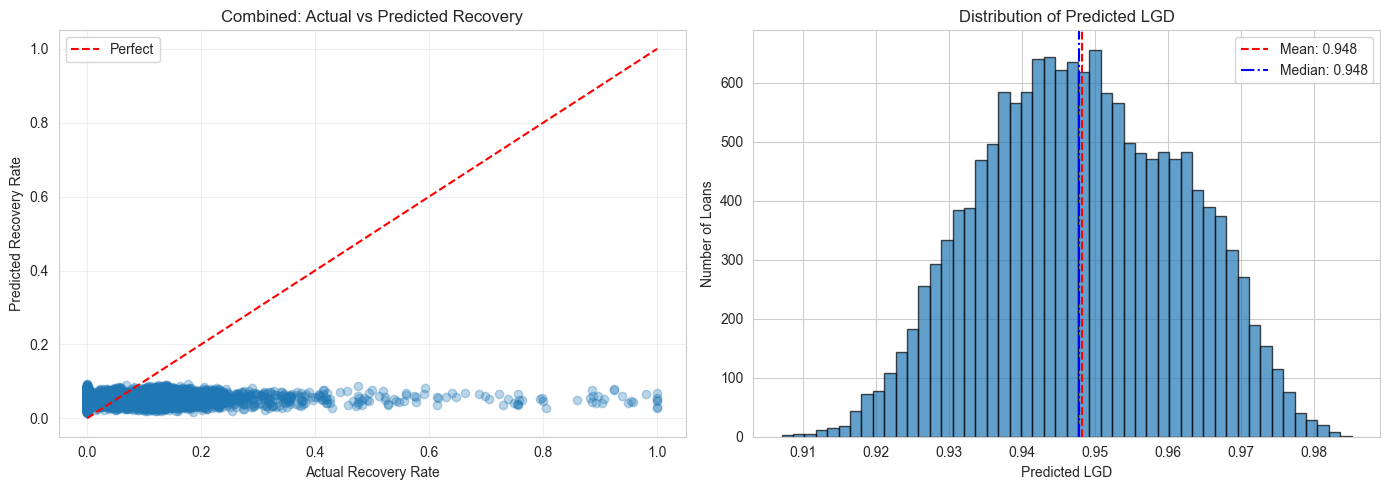

In [437]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(actual_recovery_all, final_pred_recovery, alpha=0.3)
axes[0].plot([0, 1], [0, 1], 'r--', label='Perfect')
axes[0].set_xlabel('Actual Recovery Rate')
axes[0].set_ylabel('Predicted Recovery Rate')
axes[0].set_title('Combined: Actual vs Predicted Recovery')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(lgd_predicted, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=lgd_predicted.mean(), color='red', linestyle='--', label=f'Mean: {lgd_predicted.mean():.3f}')
axes[1].axvline(x=lgd_predicted.median(), color='blue', linestyle='-.', label=f'Median: {lgd_predicted.median():.3f}')
axes[1].set_xlabel('Predicted LGD')
axes[1].set_ylabel('Number of Loans')
axes[1].set_title('Distribution of Predicted LGD')
axes[1].legend()

plt.tight_layout()
plt.show()

In [438]:
print("Summary of LGD Model:")
print(f"  Stage 1 (Classification): AUC = {auc_l1_refit:.4f}")
print(f"  Stage 2 (Regression): R² = {model_l2_refit.rsquared:.4f}")
print(f"  Combined LGD: Mean = {lgd_predicted.mean():.4f}, Median = {lgd_predicted.median():.4f}")

Summary of LGD Model:
  Stage 1 (Classification): AUC = 0.6766
  Stage 2 (Regression): R² = 0.0597
  Combined LGD: Mean = 0.9482, Median = 0.9479


In [439]:
df_defaults['CCF'] = (df_defaults['funded_amnt'] - df_defaults['total_rec_prncp']) / df_defaults['funded_amnt']

df_defaults['CCF'] = df_defaults['CCF'].clip(0, 1)

print(f"\nCCF Statistics:")
print(df_defaults['CCF'].describe())


CCF Statistics:
count    50968.000000
mean         0.719322
std          0.204788
min          0.000000
25%          0.608275
50%          0.769436
75%          0.876693
max          1.000000
Name: CCF, dtype: float64


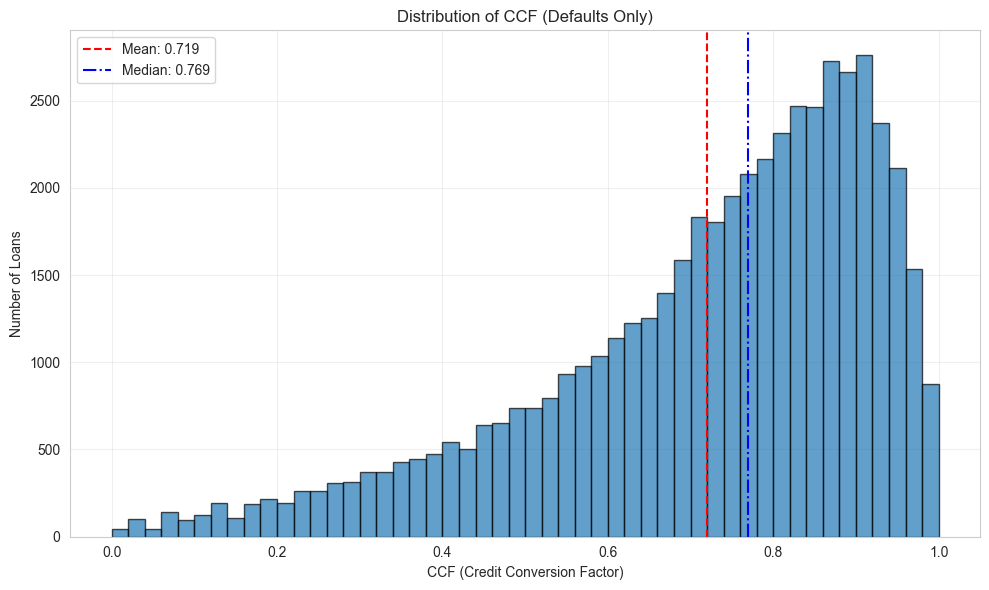

In [440]:
plt.figure(figsize=(10, 6))
plt.hist(df_defaults['CCF'], bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=df_defaults['CCF'].mean(), color='red', linestyle='--', label=f'Mean: {df_defaults["CCF"].mean():.3f}')
plt.axvline(x=df_defaults['CCF'].median(), color='blue', linestyle='-.', label=f'Median: {df_defaults["CCF"].median():.3f}')
plt.xlabel('CCF (Credit Conversion Factor)')
plt.ylabel('Number of Loans')
plt.title('Distribution of CCF (Defaults Only)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [441]:
print(f"\nLoans with CCF = 1: {(df_defaults['CCF'] == 1).sum():,} ({(df_defaults['CCF'] == 1).mean():.1%})")
print(f"Loans with CCF = 0: {(df_defaults['CCF'] == 0).sum():,} ({(df_defaults['CCF'] == 0).mean():.1%})")


Loans with CCF = 1: 399 (0.8%)
Loans with CCF = 0: 3 (0.0%)


In [442]:
X_ead = df_defaults[woe_cols].copy()
y_ead = df_defaults['CCF']

print(f"Features: {X_ead.shape[1]}")
print(f"Rows: {X_ead.shape[0]:,}")
print(f"Missing values in X: {X_ead.isnull().sum().sum()}")

Features: 12
Rows: 50,968
Missing values in X: 0


In [443]:
X_train_ead, X_test_ead, y_train_ead, y_test_ead = train_test_split(
    X_ead, y_ead, test_size=0.30, random_state=42
)

print(f"\nTraining: {X_train_ead.shape[0]:,} rows")
print(f"Test: {X_test_ead.shape[0]:,} rows")


Training: 35,677 rows
Test: 15,291 rows


In [444]:
X_train_ead_const = sm.add_constant(X_train_ead)
X_test_ead_const = sm.add_constant(X_test_ead)

model_ead = sm.OLS(y_train_ead, X_train_ead_const).fit()

print(model_ead.summary())

                            OLS Regression Results                            
Dep. Variable:                    CCF   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     711.1
Date:                Wed, 22 Jul 2026   Prob (F-statistic):               0.00
Time:                        22:56:46   Log-Likelihood:                 9826.1
No. Observations:               35677   AIC:                        -1.963e+04
Df Residuals:                   35664   BIC:                        -1.952e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [445]:
y_pred_ead = model_ead.predict(X_test_ead_const)

r2_ead = r2_score(y_test_ead, y_pred_ead)
mae_ead = mean_absolute_error(y_test_ead, y_pred_ead)
rmse_ead = np.sqrt(((y_test_ead - y_pred_ead) ** 2).mean())

print("EAD MODEL PERFORMANCE")
print(f"R²:  {r2_ead:.4f}")
print(f"MAE: {mae_ead:.4f}")
print(f"RMSE: {rmse_ead:.4f}")

EAD MODEL PERFORMANCE
R²:  0.1917
MAE: 0.1421
RMSE: 0.1847


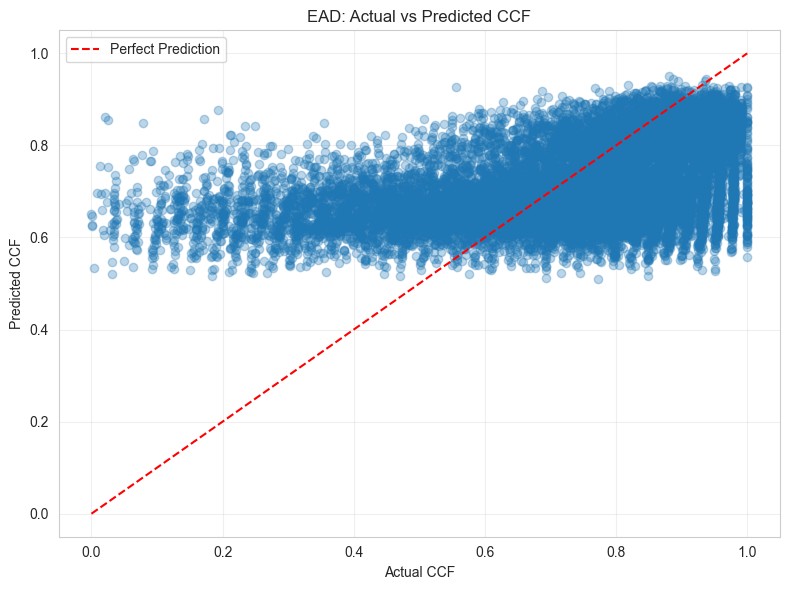

In [446]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_ead, y_pred_ead, alpha=0.3)
plt.plot([0, 1], [0, 1], 'r--', label='Perfect Prediction')
plt.xlabel('Actual CCF')
plt.ylabel('Predicted CCF')
plt.title('EAD: Actual vs Predicted CCF')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [447]:
print(f"\nCCF Statistics:")
print(f"  Actual Mean CCF: {y_test_ead.mean():.4f}")
print(f"  Predicted Mean CCF: {model_ead.predict(X_test_ead_const).mean():.4f}")


CCF Statistics:
  Actual Mean CCF: 0.7208
  Predicted Mean CCF: 0.7191


In [450]:
pd_features = [f for f in model_refit.params.index if f != 'const']
print(f"PD features ({len(pd_features)}):")
print(pd_features)

l1_features = [f for f in model_l1_refit.params.index if f != 'const']
print(f"\nLGD Stage 1 features ({len(l1_features)}):")
print(l1_features)

l2_features = [f for f in model_l2_refit.params.index if f != 'const']
print(f"\nLGD Stage 2 features ({len(l2_features)}):")
print(l2_features)

ead_features = [f for f in model_ead.params.index if f != 'const']
print(f"\nEAD features ({len(ead_features)}):")
print(ead_features)

PD features (12):
['int_rate_bin_woe', 'home_ownership_woe', 'annual_inc_bin_woe', 'verification_status_woe', 'purpose_woe', 'dti_bin_woe', 'inq_last_6mths_woe', 'revol_util_bin_woe', 'initial_list_status_woe', 'tot_cur_bal_bin_woe', 'total_rev_hi_lim_bin_woe', 'term_int_woe']

LGD Stage 1 features (10):
['int_rate_bin_woe', 'home_ownership_woe', 'annual_inc_bin_woe', 'verification_status_woe', 'purpose_woe', 'dti_bin_woe', 'inq_last_6mths_woe', 'revol_util_bin_woe', 'initial_list_status_woe', 'tot_cur_bal_bin_woe']

LGD Stage 2 features (6):
['int_rate_bin_woe', 'annual_inc_bin_woe', 'dti_bin_woe', 'revol_util_bin_woe', 'initial_list_status_woe', 'tot_cur_bal_bin_woe']

EAD features (12):
['int_rate_bin_woe', 'home_ownership_woe', 'annual_inc_bin_woe', 'verification_status_woe', 'purpose_woe', 'dti_bin_woe', 'inq_last_6mths_woe', 'revol_util_bin_woe', 'initial_list_status_woe', 'tot_cur_bal_bin_woe', 'total_rev_hi_lim_bin_woe', 'term_int_woe']


In [456]:
if 'funded_amnt' not in df_woe.columns:
    df_woe['funded_amnt'] = df['funded_amnt']

X_pd = df_woe[pd_features].astype(float)
X_pd_const = sm.add_constant(X_pd)
pd_pred = model_refit.predict(X_pd_const)

X_l1 = df_woe[l1_features].astype(float)
X_l1_const = sm.add_constant(X_l1)
prob_recovery = model_l1_refit.predict(X_l1_const)

X_l2 = df_woe[l2_features].astype(float)
X_l2_const = sm.add_constant(X_l2)
pred_recovery_amount = model_l2_refit.predict(X_l2_const)

pred_recovery = prob_recovery * pred_recovery_amount
lgd_pred = 1 - pred_recovery

X_ead = df_woe[ead_features].astype(float)
X_ead_const = sm.add_constant(X_ead)
ccf_pred = model_ead.predict(X_ead_const)
ead_pred = ccf_pred * df_woe['funded_amnt']

el_pred = pd_pred * lgd_pred * ead_pred

In [458]:
total_loans = len(df_final)
total_funded = df_woe['funded_amnt'].sum()
total_el = el_pred.sum()
el_ratio = total_el / total_funded * 100

print(f"Total Loans: {total_loans:,}")
print(f"Total Funded Amount: ${total_funded:,.0f}")
print(f"\nAverage PD: {pd_pred.mean():.2%}")
print(f"Average LGD: {lgd_pred.mean():.2%}")
print(f"Average EAD: ${ead_pred.mean():,.0f}")
print(f"Average EL per Loan: ${el_pred.mean():,.2f}")
print(f"\nTotal Expected Loss: ${total_el:,.0f}")
print(f"EL as % of Funded Amount: {el_ratio:.2f}%")

Total Loans: 466,285
Total Funded Amount: $6,664,052,450

Average PD: 10.93%
Average LGD: 95.29%
Average EAD: $10,221
Average EL per Loan: $1,077.29

Total Expected Loss: $502,324,787
EL as % of Funded Amount: 7.54%


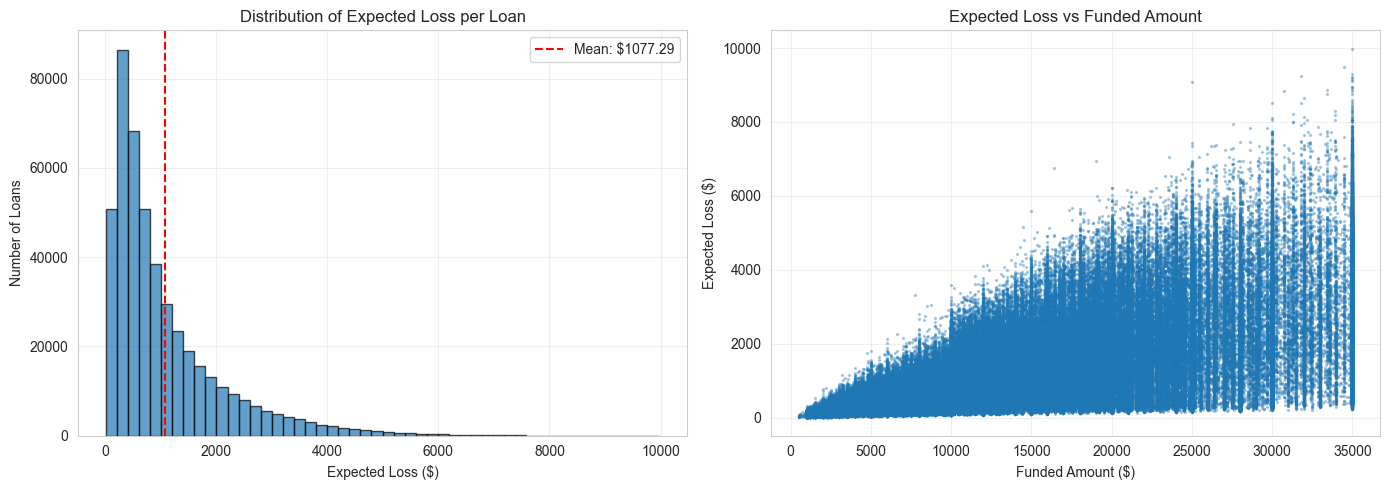

In [459]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(el_pred, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=el_pred.mean(), color='red', linestyle='--', 
                label=f'Mean: ${el_pred.mean():.2f}')
axes[0].set_xlabel('Expected Loss ($)')
axes[0].set_ylabel('Number of Loans')
axes[0].set_title('Distribution of Expected Loss per Loan')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df_woe['funded_amnt'], el_pred, alpha=0.3, s=2)
axes[1].set_xlabel('Funded Amount ($)')
axes[1].set_ylabel('Expected Loss ($)')
axes[1].set_title('Expected Loss vs Funded Amount')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [460]:
print(f"PD Model: AUC = {auc:.4f}")
print(f"LGD Model: Mean LGD = {lgd_pred.mean():.4f}")
print(f"EAD Model: R² = {r2_ead:.4f}")
print(f"Portfolio EL: ${total_el:,.0f} ({el_ratio:.2f}% of funded amount)")

PD Model: AUC = 0.6822
LGD Model: Mean LGD = 0.9529
EAD Model: R² = 0.1917
Portfolio EL: $502,324,787 (7.54% of funded amount)
